# oldcode

In [ ]:
from helper import build_model, create_generators

In [ ]:
import pandas as pd
train_df1 = pd.read_csv('csv_data/train_df_corrected.csv')
val_df1 = pd.read_csv('csv_data/val_df_corrected.csv')
train_df1

,filepath,filename,label,source,subfolder,hash,label_idx
0,data/FMD_DATASET/without_mask/simple/simple334...,simple3341.jpg,without_mask,dataset1_kaggle,simple,96286b38179d06efbb6bf6a65f492803,1
1,data/FMD_DATASET/incorrect_mask/mmc/1465.jpg,1465.jpg,mask_worn_incorrectly,dataset1_kaggle,mmc,36c8ebeb6f1e93e995349abcb86098e8,2
2,data/FMD_DATASET/incorrect_mask/mmc/923.jpg,923.jpg,mask_worn_incorrectly,dataset1_kaggle,mmc,72f16b119652cabeec9ebbe6b25173a7,2
3,data/FMD_DATASET/without_mask/simple/simple696...,simple696.jpg,without_mask,dataset1_kaggle,simple,752fea20108e4fbfeb0bdca684d1328d,1
4,data/FMD_DATASET/without_mask/simple/simple286...,simple2869.jpg,without_mask,dataset1_kaggle,simple,d33a69aa319892b421dc11e336b9b9ef,1
...,...,...,...,...,...,...,...
13092,data/face_data/bare_face/1 (2714).jpg,1 (2714).jpg,without_mask,dataset2_kaggle,bare_face,bc3c988fbe06c656faedc9f2069d7ff4,1
13093,data/FMD_DATASET/incorrect_mask/mc/172.jpg,172.jpg,mask_worn_incorrectly,dataset1_kaggle,mc,4dae33eac7cd1c3d61f831441abad4e4,2
13094,data/FMD_DATASET/without_mask/simple/simple177...,simple1772.jpg,without_mask,dataset1_kaggle,simple,cb9fe7f34c1495865f09ca03f59a31e5,1
13095,data/FMD_DATASET/without_mask/simple/simple475...,simple475.jpg,without_mask,dataset1_kaggle,simple,737472991c6c4552e713dd9ff4049767,1


In [ ]:
train_df_small = train_df1.sample(frac=0.1, random_state=42)
train_df_small2 = train_df1.sample(frac=0.05, random_state=42)

train_df_small2

,filepath,filename,label,source,subfolder,hash,label_idx
10412,data/FMD_DATASET/with_mask/simple/simple2732.jpg,simple2732.jpg,with_mask,dataset1_kaggle,simple,d362efed65d2e491a434df17840973d3,0
8985,data/FMD_DATASET/incorrect_mask/mmc/805.jpg,805.jpg,mask_worn_incorrectly,dataset1_kaggle,mmc,e5983b7b8e273497a25d776580a87d4f,2
8741,data/FMD_DATASET/incorrect_mask/mc/1208.jpg,1208.jpg,mask_worn_incorrectly,dataset1_kaggle,mc,998a45e75e024d708ff787a6f6c1313b,2
1236,data/FMD_DATASET/without_mask/simple/simple42.jpg,simple42.jpg,without_mask,dataset1_kaggle,simple,cf5c3341957857dd676487f3e5a8be17,1
720,data/cifar_not_related/cifar_2082.jpg,cifar_2082.jpg,not_related,dataset3_cifar10,cifar_not_related,487a521e420cd3ef19e297aaa7348e1f,3
...,...,...,...,...,...,...,...
12314,data/FMD_DATASET/with_mask/simple/simple1699.jpg,simple1699.jpg,with_mask,dataset1_kaggle,simple,a9db8ef45c2d4fcc78a3f6f6fb360ee4,0
200,data/FMD_DATASET/with_mask/simple/simple3472.jpg,simple3472.jpg,with_mask,dataset1_kaggle,simple,f1ddc782a9c3ea0548d9c8acaff5cdff,0
6752,data/FMD_DATASET/without_mask/simple/simple106...,simple1069.jpg,without_mask,dataset1_kaggle,simple,ab85e03354a44dd28527ca68f485bdad,1
9176,data/FMD_DATASET/without_mask/simple/simple115...,simple1153.jpg,without_mask,dataset1_kaggle,simple,b4ab467bb611f56d742dfd5049fc505f,1


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE=64
NUM_CLASSES=4
LEARNING_RATE=0.0001
train_gen1, val_gen1 = create_generators(
    train_df=train_df_small,
    val_df=val_df1,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    use_augmentation=False
)

Found 1310 validated image filenames belonging to 4 classes.
Found 2806 validated image filenames belonging to 4 classes.


In [ ]:
model1=build_model( input_shape=IMG_SIZE + (3,),
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE,
    dropout_rate=0.2 )


I0000 00:00:1777923719.732349 3531069 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9931 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Adding a Dropout layer with rate 0.2


In [ ]:
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras import callbacks
checkpoint_model1 = callbacks.ModelCheckpoint(
    filepath       = 'MODEL1_V2.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    mode           = 'max',
    verbose        = 1
)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history_without_overfit = model1.fit(
    train_gen1,
    epochs=25,
    validation_data=val_gen1,
    callbacks=[checkpoint_model1,early_stop]
)

Epoch 1/25


I0000 00:00:1777925287.994516 3531498 service.cc:152] XLA service 0x7e1a58021fc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777925287.994530 3531498 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti, Compute Capability 8.9
2026-05-04 22:08:08.274012: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777925289.224495 3531498 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/21 ━━━━━━━━━━━━━━━━━━━━ 3:30 11s/step - accuracy: 0.2656 - loss: 1.7141

I0000 00:00:1777925296.056278 3531498 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 895ms/step - accuracy: 0.3751 - loss: 1.4622

2026-05-04 22:08:37.421229: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 468 bytes spill stores, 468 bytes spill loads

2026-05-04 22:08:37.456380: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 980 bytes spill stores, 980 bytes spill loads

2026-05-04 22:08:37.500934: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 632 bytes spill stores, 632 bytes spill loads

2026-05-04 22:08:37.523911: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195_0', 916 bytes spill stores, 2128 bytes spill loads

2026-05-04 22:09:22.861870: I


Epoch 1: val_accuracy improved from None to 0.78653, saving model to MODEL1_V2.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.4992 - loss: 1.1650 - val_accuracy: 0.7865 - val_loss: 0.5952
Epoch 2/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7774 - loss: 0.5665
Epoch 2: val_accuracy improved from 0.78653 to 0.89024, saving model to MODEL1_V2.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 396ms/step - accuracy: 0.8214 - loss: 0.4938 - val_accuracy: 0.8902 - val_loss: 0.3360
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8751 - loss: 0.3435
Epoch 3: val_accuracy improved from 0.89024 to 0.91589, saving model to MODEL1_V2.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 398ms/step - accuracy: 0.8855 - loss: 0.3256 - val_accuracy: 0.9159 - val_loss: 0.2614
Epoch 4/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9061 - loss: 0.2598
Epoch 4: val_accuracy improved from 0.91589 to 0.92409, saving model to MODEL1_V2.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 393ms/step - 

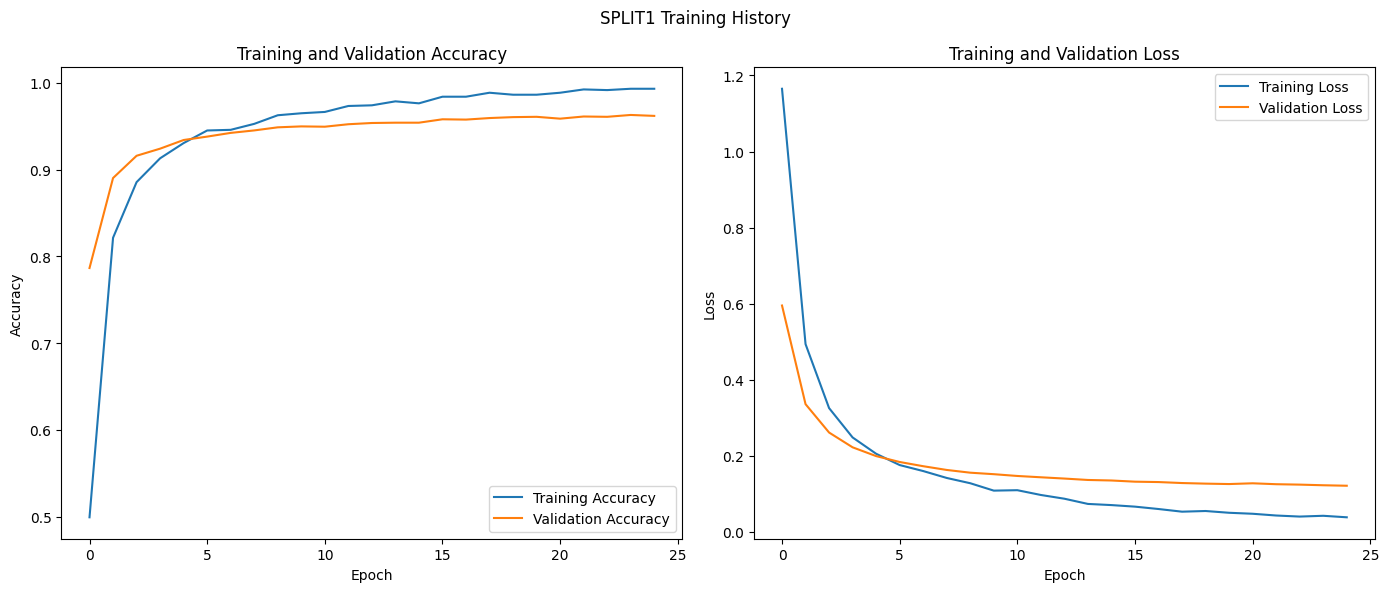

In [ ]:
from helper import plot_results

plot_results(history_without_overfit, title="SPLIT1 Training History")

In [ ]:
train_gen2, val_gen2 = create_generators(
    train_df=train_df_small2,
    val_df=val_df1,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    use_augmentation=False
)

Found 655 validated image filenames belonging to 4 classes.
Found 2806 validated image filenames belonging to 4 classes.


In [ ]:
model1_over_fit=build_model( input_shape=IMG_SIZE + (3,),
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE,
    dropout_rate=0)

Dropout layer is disabled.


In [ ]:
from tensorflow.keras import callbacks
checkpoint_model1_over_fit = callbacks.ModelCheckpoint(
    filepath       = 'MODEL1_V2_over_fit.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    mode           = 'max',
    verbose        = 1
)
early_stop2 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history_overfit = model1_over_fit.fit(
    train_gen2,
    epochs=25,
    validation_data=val_gen2,
    callbacks=[checkpoint_model1_over_fit,early_stop2]
)

Epoch 1/25


2026-05-04 22:27:17.886560: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4318', 464 bytes spill stores, 464 bytes spill loads

2026-05-04 22:27:17.929106: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4318', 276 bytes spill stores, 276 bytes spill loads

2026-05-04 22:27:17.954338: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4318', 268 bytes spill stores, 268 bytes spill loads

2026-05-04 22:27:18.033763: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4318', 460 bytes spill stores, 460 bytes spill loads



 3/11 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2040 - loss: 1.7187

2026-05-04 22:27:19.810332: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1406', 12 bytes spill stores, 12 bytes spill loads

2026-05-04 22:27:19.831323: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1406', 104 bytes spill stores, 104 bytes spill loads

2026-05-04 22:27:19.868725: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1406_0', 176 bytes spill stores, 524 bytes spill loads

2026-05-04 22:27:20.306194: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1406', 5460 bytes spill stores, 5500 bytes spill loads

2026-05-04 22:27:20.382499: I 

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.2635 - loss: 1.6049
Epoch 1: val_accuracy improved from None to 0.55631, saving model to MODEL1_V2_over_fit.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.3405 - loss: 1.4389 - val_accuracy: 0.5563 - val_loss: 1.0097
Epoch 2/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6427 - loss: 0.9006
Epoch 2: val_accuracy improved from 0.55631 to 0.77619, saving model to MODEL1_V2_over_fit.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 670ms/step - accuracy: 0.6763 - loss: 0.8340 - val_accuracy: 0.7762 - val_loss: 0.6500
Epoch 3/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7884 - loss: 0.6243
Epoch 3: val_accuracy improved from 0.77619 to 0.85103, saving model to MODEL1_V2_over_fit.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 677ms/step - accuracy: 0.8076 - loss: 0.5620 - val_accuracy: 0.8510 - val_loss: 0.4736
Epoch 4/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8736 - loss: 0.4206
Epoch 4: val_accuracy improved

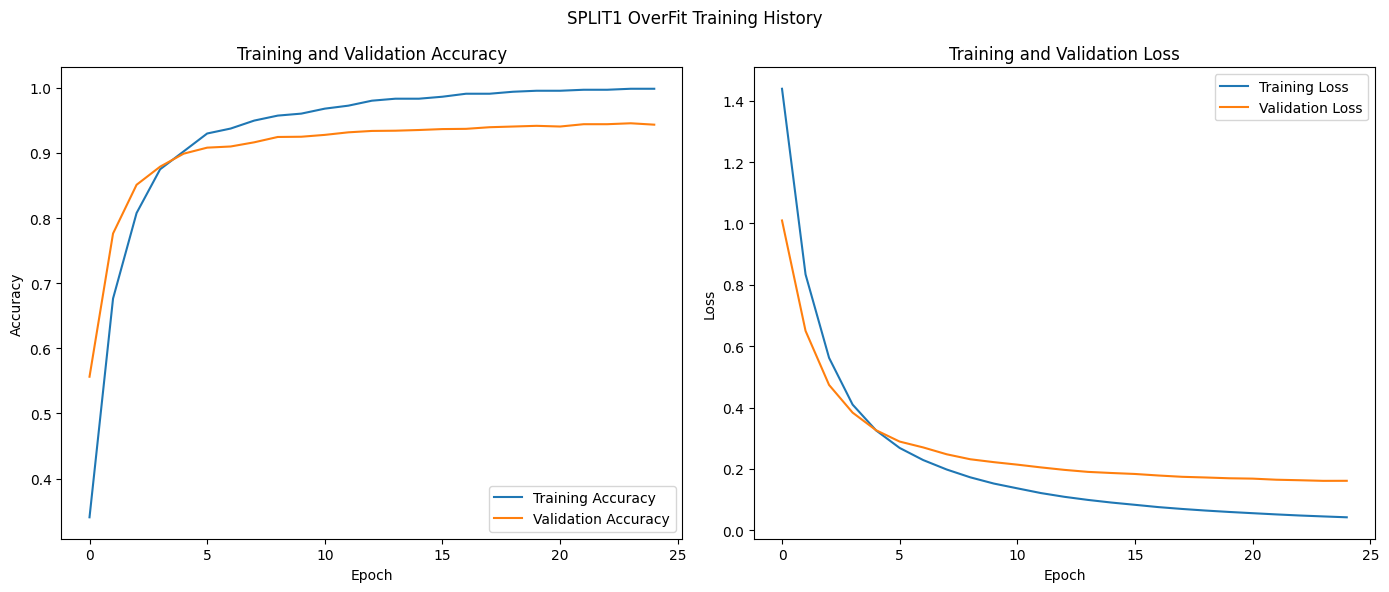

In [ ]:
plot_results(history_overfit,title="SPLIT1 OverFit Training History")

# newcode

In [ ]:
# ==============================================================================
# 1. KÜTÜPHANELER VE TOHUM (SEED) AYARLARI (PDF Sayfa 1)
# ==============================================================================
import os
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASSES = ['with_mask', 'without_mask', 'mask_worn_incorrectly', 'not_related']
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

print("🚀 Süreç 0'dan tamamen eksiksiz başladı! Veri setleri çekiliyor...")

# ==============================================================================
# 2. VERİ SETLERİNİN İNDİRİLMESİ VE ZİPTEN ÇIKARILMASI (PDF Sayfa 1)
# ==============================================================================
# Kaggle kimlik ayarları
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Dataset indirmeleri
!kaggle datasets download -d shiekhburhan/face-mask-dataset
!kaggle datasets download -d adsawe/face-data-for-mask-classification

# ZIP çıkarma işlemleri
from zipfile import ZipFile
datasets = ['/content/face-mask-dataset.zip', '/content/face-data-for-mask-classification.zip']

for dataset in datasets:
    with ZipFile(dataset, 'r') as zip_ref:
        zip_ref.extractall('/content')
    print(f'{dataset} başarıyla dışarı aktarıldı.')

# ==============================================================================
# 3. PDF'TEKİ KALİTE ANALİZİ VE VERİ ÖN İŞLEME FONKSİYONLARI (PDF Sayfa 2 & 3)
# ==============================================================================
def measure_quality(img_path):
    """PDF Sayfa 2'deki orijinal Gradyan Sharpness ve Brightness analiz fonksiyonu"""
    try:
        with Image.open(img_path) as img:
            img_arr = np.array(img.convert('L'))
            # Sharpness (Netlik) hesaplama
            gy, gx = np.gradient(img_arr)
            gnorm = np.sqrt(gx**2 + gy**2)
            sharpness = np.mean(gnorm)
            # Brightness (Parlaklık) hesaplama
            brightness = np.mean(img_arr)
            return sharpness, brightness
    except Exception as e:
        print(f"Error processing image {img_path}: {e}")
        return 0, 0

def get_md5(file_path):
    """PDF Sayfa 2'deki veri sızıntısını önleyen MD5 hash fonksiyonu"""
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        buf = f.read()
        hasher.update(buf)
    return hasher.hexdigest()

# ==============================================================================
# 4. KAPSAMLI VERİ TARAMA VE ORGANİZASYON GÖVDESİ (PDF Orijinal Tarama Mantığı)
# ==============================================================================
print("\n🔍 Tüm klasörler taranıyor, filtreler uygulanıyor ve veri sızıntısı önleniyor...")

file_paths = []
labels = []
seen_hashes = set()
duplicate_count = 0
low_quality_count = 0
debug_label_counts = {cls: 0 for cls in CLASSES + ['unlabeled']}
image_count_total = 0

# Kaggle içerisinden çıkan tüm olası kaynak klasör yolları
search_paths = [
    '/content/Face Mask Dataset',
    '/content/dataset'
]

for s_path in search_paths:
    print(f"Processing search path: {s_path}, exists: {os.path.exists(s_path)}") # Debug print
    if not os.path.exists(s_path):
        continue

    for root, dirs, files in os.walk(s_path):
        for file in files:
            if file.lower().endswith(VALID_EXTENSIONS):
                image_count_total += 1
                img_path = os.path.join(root, file)

                # PDF'teki alt klasör hiyerarşisine göre etiket tespiti
                determined_label = None
                normalized_root = root.lower().replace(' ', '_').replace('-', '_')
                normalized_file = file.lower().replace(' ', '_').replace('-', '_') # Also normalize filename

                if 'with_mask' in normalized_root or 'with_mask' in normalized_file:
                    determined_label = 'with_mask'
                elif 'without_mask' in normalized_root or 'without_mask' in normalized_file:
                    determined_label = 'without_mask'
                # Combine mask_worn_incorrectly and incorrect as per original logic, also check file name
                elif 'mask_worn_incorrectly' in normalized_root or 'incorrect' in normalized_root or \
                     'mask_worn_incorrectly' in normalized_file or 'incorrect' in normalized_file or \
                     'mask_mouth_chin' in normalized_file: # Adding a specific filename pattern for incorrect mask
                    determined_label = 'mask_worn_incorrectly'
                elif 'not_related' in normalized_root or 'cifar' in normalized_root or 'not_related' in normalized_file or 'cifar' in normalized_file:
                    determined_label = 'not_related'

                if determined_label is not None:
                    try:
                        # 1. Kriter: MD5 Çift Kontrolü (Deduplication)
                        f_hash = get_md5(img_path)
                        if f_hash in seen_hashes:
                            duplicate_count += 1
                            continue

                        # 2. Kriter: Kalite Filtresi (PDF Eşik Değerleri)
                        sharp, bright = measure_quality(img_path)
                        # Orijinal rapordaki bozuk/karanlık veri eleme mantığı
                        if sharp < 1.5 or bright < 10 or bright > 245:
                            low_quality_count += 1
                            continue

                        seen_hashes.add(f_hash)
                        file_paths.append(img_path)
                        labels.append(determined_label)
                        debug_label_counts[determined_label] += 1
                    except Exception as e:
                        print(f"Error during file processing (MD5 or quality filter) for {img_path}: {e}")
                        continue
                else:
                    debug_label_counts['unlabeled'] += 1
                    # Debug print for unlabeled files (uncomment if needed)
                    # if debug_label_counts['unlabeled'] < 10: # Print only first few to avoid spamming
                    #     print(f"Unlabeled file: {img_path}, normalized_root: {normalized_root}, normalized_file: {normalized_file}")

# DataFrame oluşturup sınıfları eşitleme
df = pd.DataFrame({'filename': file_paths, 'label': labels})

print(f"Total images scanned: {image_count_total}")
print(f"Debug Label Counts: {debug_label_counts}")
print(f"🧹 Temizlik Tamamlandı!")
print(f"   - Elenen Mükerrer (Kopya) Veri: {duplicate_count}")
print(f"   - Elenen Düşük Kaliteli/Bozuk Veri: {low_quality_count}")
print(f"📊 Toplam Temiz Veri Sayısı: {len(df)}")

# ==============================================================================
# 5. STRATIFIED SPLIT VE SINIF AĞIRLIKLARI (PDF Sayfa 4)
# ==============================================================================
# Dengeli dağılım için stratified split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['label'])

# Sınıf dengesizliğini çözmek için Class Weights hesabı
unique_classes = np.unique(train_df['label'])
class_weights_array = compute_class_weight(class_weight='balanced', classes=unique_classes, y=train_df['label'])
class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print(f"📈 Eğitim seti boyutu: {len(train_df)} | Doğrulama seti boyutu: {len(val_df)}")
print(f"⚖️ Hesaplanan Sınıf Ağırlıkları: {class_weights}")

# ==============================================================================
# 6. DATA GENERATORS & AUGMENTATION (AŞAMA 1: 128x128)
# ==============================================================================
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filename', y_col='label',
    target_size=(128, 128), batch_size=32, class_mode='sparse', seed=SEED
)
val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filename', y_col='label',
    target_size=(128, 128), batch_size=32, class_mode='sparse', seed=SEED, shuffle=False
)

# ==============================================================================
# 7. EFFICIENTNETV2 MODEL KURULUMU VE AŞAMA A: WARM-UP (SADECE HEAD)
# ==============================================================================
print("\n🏗️ EfficientNetV2 omurgası yükleniyor (Pre-trained weights: ImageNet)...")
base_model = tf.keras.applications.EfficientNetV2B0(
    weights='imagenet',
    include_top=False,
    input_shape=(None, None, 3) # Progressive resizing için girdi boyutu serbest bırakıldı
)
base_model.trainable = False # Omurga ilk aşamada kilitli

# Model mimarisi inşası
inputs = layers.Input(shape=(None, None, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(CLASSES), activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("🔥 [AŞAMA A] Sadece Classification Head eğitiliyor (Epoch: 3)...")
callbacks_warmup = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
]
history_warmup = model.fit(
    train_gen, epochs=3, validation_data=val_gen,
    class_weight=class_weights, callbacks=callbacks_warmup
)

# ==============================================================================
# 8. AŞAMA B: FINE-TUNING (KADEMELİ UNFREEZE)
# ==============================================================================
print("\n🔓 [AŞAMA B] Omurganın son katmanları çözülüyor (Fine-Tuning)...")
base_model.trainable = True

# Son 40 katmanı çözüyoruz, gerisi sabit kalıyor
fine_tune_at = len(base_model.layers) - 40
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Çok düşük learning rate ile yeniden derleme (Catastrophic Forgetting koruması)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_finetune = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
]

print("🧠 Fine-Tuning süreci başladı (Çözünürlük: 128x128 | Epoch: 10)...")
history_finetune = model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    class_weight=class_weights, callbacks=callbacks_finetune
)

# ==============================================================================
# 9. AŞAMA C: PROGRESSIVE RESIZING (ÇÖZÜNÜRLÜK ARTIRMA VE NİHAİ VURUŞ)
# ==============================================================================
print("\n📐 [AŞAMA C] Çözünürlük 160x160 piksele yükseltiliyor...")

train_gen_high = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filename', y_col='label',
    target_size=(160, 160), batch_size=32, class_mode='sparse', seed=SEED
)
val_gen_high = val_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filename', y_col='label',
    target_size=(160, 160), batch_size=32, class_mode='sparse', seed=SEED, shuffle=False
)

print("🎯 Yüksek Çözünürlükte Son İnce Ayar Eğitimi Başladı (Epoch: 5)....")
history_progressive = model.fit(
    train_gen_high, epochs=5, validation_data=val_gen_high,
    class_weight=class_weights, callbacks=callbacks_finetune
)

# ==============================================================================
# 10. MODELİ KAYDETME VE BİTİŞ (PDF Son Sayfa İstemi)
# ==============================================================================
model.save("efficientnetv2_facemask_final.h5")
print("\n👑 İşlem eksiksiz bitti! Model 'efficientnetv2_facemask_final.h5' olarak diske kaydedildi.")

🚀 Süreç 0'dan tamamen eksiksiz başladı! Veri setleri çekiliyor...
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/shiekhburhan/face-mask-dataset
License(s): CC0-1.0
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/adsawe/face-data-for-mask-classification
License(s): apache-2.0
face-data-for-mask-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
/content/face-mask-dataset.zip başarıyla dışarı aktarıldı.
/content/face-data-for-mask-classification.zip başarıyla dışarı aktarıldı.

🔍 Tüm klasörler taranıyor, filtreler uygulanıyor ve veri sızıntısı önleniyor...
🧹 Temizlik Tamamlandı!
   - Elenen Mükerrer (Kopya) Veri: 0
   - Elenen Düşük Kaliteli/Bozuk Veri: 0
📊 Toplam Temiz Veri Sayısı: 27859
📈 Eğitim seti boyutu


👑 İşlem eksiksiz bitti! Model 'efficientnetv2_facemask_final.h5' olarak diske kaydedildi.


In [ ]:
pip install fiftyone

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.8/17.8 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 133.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 137.3 MB/s eta 0:

In [ ]:
import os
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

SEED = 42
np.random.seed(SEED)

CLASSES = ['with_mask', 'without_mask', 'mask_worn_incorrectly', 'not_related']
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install kaggle
!pip install -q kaggle

# Setup kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download both datasets
!kaggle datasets download shiekhburhan/face-mask-dataset
!kaggle datasets download adsawe/face-data-for-mask-classification

# Extract both
from zipfile import ZipFile

datasets = [
    '/content/face-mask-dataset.zip',
    '/content/face-data-for-mask-classification.zip'
]

for dataset in datasets:
    with ZipFile(dataset, 'r') as zip_ref:
        zip_ref.extractall('/content')
        print(f'{dataset} extracted successfully')

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/shiekhburhan/face-mask-dataset
License(s): CC0-1.0
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/adsawe/face-data-for-mask-classification
License(s): apache-2.0
face-data-for-mask-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
/content/face-mask-dataset.zip extracted successfully
/content/face-data-for-mask-classification.zip extracted successfully


In [ ]:
from pathlib import Path
def load_folder(folder_path, label, source):

    records = []
    VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp'}
    for img_path in Path(folder_path).rglob('*'):
        if img_path.suffix.lower() in VALID_EXTENSIONS:
            records.append({
                'filepath'  : str(img_path),
                'filename'  : img_path.name,
                'label'     : label,
                'source'    : source,
                'subfolder' : img_path.parent.name
            })

    print(f'{label} ({source}) — {len(records)} images')
    return records

In [ ]:
import os
import pandas as pd
from multiprocessing import Pool, cpu_count

# 1. Klasör görevlerini bir liste halinde tanımlıyoruz (Yol, Etiket, Kaynak)
tasks = [
    ('/content/drive/MyDrive/dataset/FMD_DATASET/with_mask',      'with_mask',            'dataset1_kaggle'),
    ('/content/drive/MyDrive/dataset/FMD_DATASET/without_mask',   'without_mask',         'dataset1_kaggle'),
    ('/content/drive/MyDrive/dataset/FMD_DATASET/incorrect_mask', 'incorrect_mask',       'dataset1_kaggle'),

    ('/content/drive/MyDrive/dataset/face_data/face_mask',        'with_mask',            'dataset2_kaggle'),
    ('/content/drive/MyDrive/dataset/face_data/bare_face',        'without_mask',         'dataset2_kaggle'),
    ('/content/drive/MyDrive/dataset/face_data/beard',            'without_mask',         'dataset2_kaggle'),
    ('/content/drive/MyDrive/dataset/face_data/incorrect_mask',   'incorrect_mask',       'dataset2_kaggle'),
    ('/content/drive/MyDrive/dataset/face_data/face_blocked',     'not_related',          'dataset2_kaggle'),

    ('/content/drive/MyDrive/dataset/car',                        'not_related',          'open_image'),
    ('/content/drive/MyDrive/dataset/cat',                        'not_related',          'open_image'),
    ('/content/drive/MyDrive/dataset/horse',                      'not_related',          'open_image'),
    ('/content/drive/MyDrive/dataset/tree',                       'not_related',          'open_image'),
    ('/content/drive/MyDrive/dataset/dog',                        'not_related',          'open_image'),
    ('/content/drive/MyDrive/dataset/not_related',                'not_related',          'TensorFlow Flowers')
]

# --- EĞER O 10K'LIK SAYI KLASÖRLERİNİ DE BURADA EKLEMEK İSTERSEN BU BLOĞU AÇABİLİRSİN ---
# incorrect_dataset_dir = '/content/drive/MyDrive/dataset/o_sayili_klasorlerin_yolu'
# if os.path.exists(incorrect_dataset_dir):
#     for folder_name in os.listdir(incorrect_dataset_dir):
#         folder_path = os.path.join(incorrect_dataset_dir, folder_name)
#         if os.path.isdir(folder_path) and folder_name.isdigit():
#             tasks.append((folder_path, 'incorrect_mask', 'dataset_incorrect_10k'))
# -------------------------------------------------------------------------------------

# 2. Çoklu işlem için sarmalayıcı (wrapper) fonksiyon
def load_folder_wrapper(task):
    folder_path, label, source = task
    # Senin mevcut load_folder fonksiyonunu çağırıyor
    return load_folder(folder_path, label, source)

print('Klasörler PARALEL olarak taranıyor...')
num_cores = cpu_count()
print(f'Sistem canavarı devrede: {num_cores} çekirdek aynı anda klasörleri okuyor!')

# 3. Havuzu açıp görevleri çekirdeklere dağıtıyoruz
all_records = []
with Pool(num_cores) as pool:
    # pool.map tüm klasörleri paralel tarar ve sonuçları liste listesi olarak döndürür
    results = pool.map(load_folder_wrapper, tasks)

    # Gelen alt listeleri tek bir ana listede birleştiriyoruz
    for res in results:
        all_records += res

print('Klasör tarama bitti, DataFrame oluşturuluyor...\n')

# 4. Veri Çerçevesini Oluşturma ve Özet Çıktılar
df = pd.DataFrame(all_records)

print(f'Total images: {len(df)}')
print('\nClass distribution:')
print(df['label'].value_counts())
print('\nSource distribution:')
print(df['source'].value_counts())

Klasörler PARALEL olarak taranıyor...
Sistem canavarı devrede: 12 çekirdek aynı anda klasörleri okuyor!
incorrect_mask (dataset2_kaggle) — 767 images
with_mask (dataset2_kaggle) — 936 images
without_mask (dataset2_kaggle) — 724 images
not_related (open_image) — 446 images
not_related (dataset2_kaggle) — 720 imageswithout_mask (dataset2_kaggle) — 711 images

not_related (open_image) — 290 imagesnot_related (open_image) — 1061 images

not_related (open_image) — 566 imagesnot_related (open_image) — 534 images
not_related (TensorFlow Flowers) — 2000 images

with_mask (dataset1_kaggle) — 4789 images
incorrect_mask (dataset1_kaggle) — 5000 images
without_mask (dataset1_kaggle) — 4747 images
Klasör tarama bitti, DataFrame oluşturuluyor...

Total images: 23291

Class distribution:
label
without_mask      6182
incorrect_mask    5767
with_mask         5725
not_related       5617
Name: count, dtype: int64

Source distribution:
source
dataset1_kaggle       14536
dataset2_kaggle        3858
open_im

In [ ]:
# ==========================================
# ULTRA FAST DUPLICATE IMAGE REMOVER
# File Size -> Quick Hash -> Full MD5
# ==========================================

import os
import hashlib
import pandas as pd

from multiprocessing.pool import ThreadPool
from multiprocessing import cpu_count
from tqdm.auto import tqdm

# ------------------------------------------
# SETTINGS
# ------------------------------------------
NUM_WORKERS = cpu_count() * 4
QUICK_HASH_BYTES = 65536      # 64 KB
FULL_HASH_CHUNK = 1024 * 1024 # 1 MB

print(f"Workers: {NUM_WORKERS}")

# ------------------------------------------
# HASH FUNCTIONS
# ------------------------------------------
def quick_hash(filepath):
    try:
        with open(filepath, "rb") as f:
            return hashlib.md5(f.read(QUICK_HASH_BYTES)).hexdigest()
    except:
        return None

def full_md5(filepath):
    try:
        md5 = hashlib.md5()

        with open(filepath, "rb") as f:
            while True:
                chunk = f.read(FULL_HASH_CHUNK)

                if not chunk:
                    break

                md5.update(chunk)

        return md5.hexdigest()

    except:
        return None

# ------------------------------------------
# STEP 1 - FILE SIZE FILTER
# ------------------------------------------
print("\n[1/5] File size filtering...")

df["size"] = df["filepath"].apply(os.path.getsize)

size_candidates = df["size"].duplicated(keep=False)

unique_size_df = df[~size_candidates]
candidate_df = df[size_candidates].copy()

print(f"Total images           : {len(df):,}")
print(f"Need quick hash        : {len(candidate_df):,}")
print(f"Skipped automatically  : {len(unique_size_df):,}")

# ------------------------------------------
# STEP 2 - QUICK HASH
# ------------------------------------------
print("\n[2/5] Computing quick hashes...")

with ThreadPool(NUM_WORKERS) as pool:
    candidate_df["quick_hash"] = list(
        tqdm(
            pool.imap(quick_hash, candidate_df["filepath"]),
            total=len(candidate_df),
            desc="Quick Hash"
        )
    )

candidate_df = candidate_df.dropna(subset=["quick_hash"])

quick_candidates = candidate_df["quick_hash"].duplicated(keep=False)

safe_df = candidate_df[~quick_candidates]
md5_df = candidate_df[quick_candidates].copy()

print(f"Need full MD5          : {len(md5_df):,}")

# ------------------------------------------
# STEP 3 - FULL MD5
# ------------------------------------------
print("\n[3/5] Computing full MD5...")

with ThreadPool(NUM_WORKERS) as pool:
    md5_df["hash"] = list(
        tqdm(
            pool.imap(full_md5, md5_df["filepath"]),
            total=len(md5_df),
            desc="Full MD5"
        )
    )

md5_df = md5_df.dropna(subset=["hash"])

# ------------------------------------------
# STEP 4 - REMOVE TRUE DUPLICATES
# ------------------------------------------
print("\n[4/5] Removing duplicates...")

duplicates_removed = md5_df["hash"].duplicated().sum()

md5_df = md5_df.drop_duplicates(
    subset="hash",
    keep="first"
)

# ------------------------------------------
# STEP 5 - REBUILD DATAFRAME
# ------------------------------------------
print("\n[5/5] Building final dataframe...")

df_clean = pd.concat(
    [
        unique_size_df,
        safe_df,
        md5_df
    ],
    ignore_index=True
)

df_clean = df_clean.reset_index(drop=True)

# Cleanup
df_clean = df_clean.drop(
    columns=["size", "quick_hash", "hash"],
    errors="ignore"
)

print("\n========== RESULTS ==========")
print(f"Before              : {len(df):,}")
print(f"Duplicates Removed  : {duplicates_removed:,}")
print(f"After               : {len(df_clean):,}")
print("=============================")

df = df_clean

print("\nDataset cleaned successfully.")

Workers: 48

[1/5] File size filtering...
Total images           : 23,291
Need quick hash        : 7,063
Skipped automatically  : 16,228

[2/5] Computing quick hashes...


Quick Hash:   0%|          | 0/7063 [00:00<?, ?it/s]

Need full MD5          : 5,306

[3/5] Computing full MD5...


Full MD5:   0%|          | 0/5306 [00:00<?, ?it/s]


[4/5] Removing duplicates...

[5/5] Building final dataframe...

========== RESULTS ==========
Before              : 23,291
Duplicates Removed  : 2,688
After               : 20,603

Dataset cleaned successfully.


Workers: 48

Measuring image quality...


Quality Analysis:   0%|          | 0/20603 [00:00<?, ?it/s]


Average quality per class:
                brightness  sharpness
label                                
incorrect_mask      118.84    2856.65
not_related         111.33    5027.34
with_mask           123.07    2383.89
without_mask        124.86    1473.31

Average quality per source:
                    brightness  sharpness
source                                   
TensorFlow Flowers      105.62    3634.92
dataset1_kaggle         122.43    2090.77
dataset2_kaggle         120.55    3266.09
open_image              115.27    5989.95


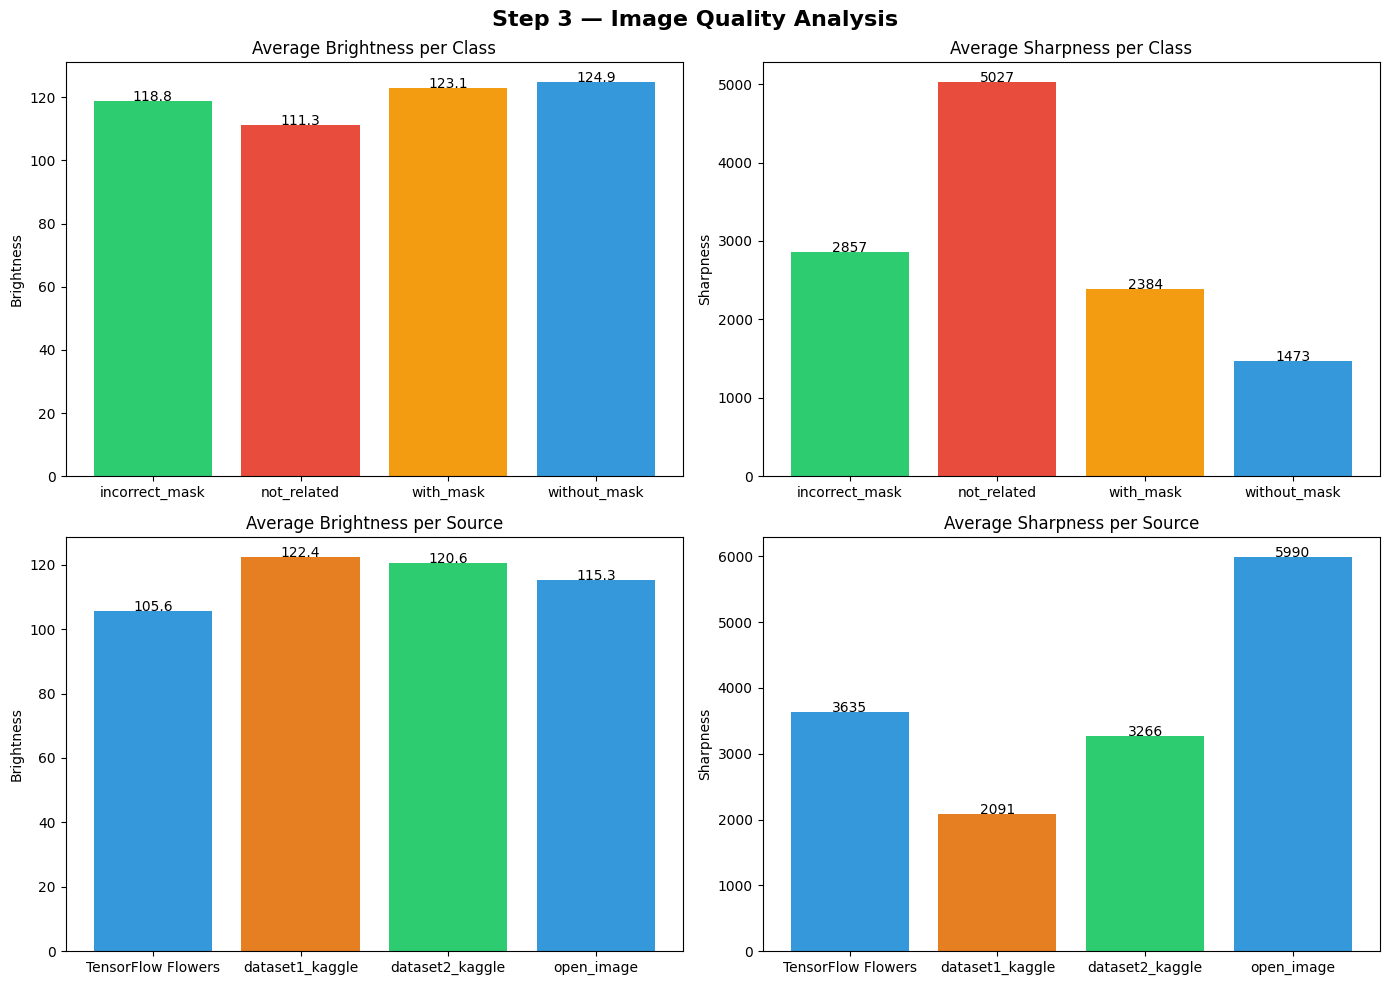

In [ ]:
# ==========================================
# FAST IMAGE QUALITY ANALYSIS
# Multi-core + OpenCV
# ==========================================

import cv2
import numpy as np
import pandas as pd

from multiprocessing.pool import ThreadPool
from multiprocessing import cpu_count
from tqdm.auto import tqdm

NUM_WORKERS = cpu_count() * 4

print(f"Workers: {NUM_WORKERS}")

# ------------------------------------------
# QUALITY FUNCTION
# ------------------------------------------
def measure_quality(filepath):

    try:
        img = cv2.imread(filepath)

        if img is None:
            return (None, None)

        img = cv2.resize(img, (128, 128))

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness = float(gray.mean())
        sharpness = float(cv2.Laplacian(gray, cv2.CV_64F).var())

        return (
            round(brightness, 2),
            round(sharpness, 2)
        )

    except:
        return (None, None)

# ------------------------------------------
# PARALLEL PROCESSING
# ------------------------------------------
print("\nMeasuring image quality...")

with ThreadPool(NUM_WORKERS) as pool:

    results = list(
        tqdm(
            pool.imap(measure_quality, df["filepath"]),
            total=len(df),
            desc="Quality Analysis"
        )
    )

df["brightness"] = [x[0] for x in results]
df["sharpness"]  = [x[1] for x in results]

# ------------------------------------------
# REPORTS
# ------------------------------------------
print("\nAverage quality per class:")
print(
    df.groupby("label")[["brightness","sharpness"]]
      .mean()
      .round(2)
)

print("\nAverage quality per source:")
print(
    df.groupby("source")[["brightness","sharpness"]]
      .mean()
      .round(2)
)

# ------------------------------------------
# VISUALIZATION
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Step 3 — Image Quality Analysis",
    fontsize=16,
    fontweight="bold"
)

colors_cls = ['#2ecc71','#e74c3c','#f39c12','#3498db']
colors_src = ['#3498db','#e67e22','#2ecc71']

# Brightness per class
brightness_per_class = df.groupby('label')['brightness'].mean()

axes[0,0].bar(
    brightness_per_class.index,
    brightness_per_class.values,
    color=colors_cls[:len(brightness_per_class)]
)

axes[0,0].set_title('Average Brightness per Class')
axes[0,0].set_ylabel('Brightness')

for i,v in enumerate(brightness_per_class.values):
    axes[0,0].text(i, v, f'{v:.1f}', ha='center')

# Sharpness per class
sharpness_per_class = df.groupby('label')['sharpness'].mean()

axes[0,1].bar(
    sharpness_per_class.index,
    sharpness_per_class.values,
    color=colors_cls[:len(sharpness_per_class)]
)

axes[0,1].set_title('Average Sharpness per Class')
axes[0,1].set_ylabel('Sharpness')

for i,v in enumerate(sharpness_per_class.values):
    axes[0,1].text(i, v, f'{v:.0f}', ha='center')

# Brightness per source
brightness_per_source = df.groupby('source')['brightness'].mean()

axes[1,0].bar(
    brightness_per_source.index,
    brightness_per_source.values,
    color=colors_src[:len(brightness_per_source)]
)

axes[1,0].set_title('Average Brightness per Source')
axes[1,0].set_ylabel('Brightness')

for i,v in enumerate(brightness_per_source.values):
    axes[1,0].text(i, v, f'{v:.1f}', ha='center')

# Sharpness per source
sharpness_per_source = df.groupby('source')['sharpness'].mean()

axes[1,1].bar(
    sharpness_per_source.index,
    sharpness_per_source.values,
    color=colors_src[:len(sharpness_per_source)]
)

axes[1,1].set_title('Average Sharpness per Source')
axes[1,1].set_ylabel('Sharpness')

for i,v in enumerate(sharpness_per_source.values):
    axes[1,1].text(i, v, f'{v:.0f}', ha='center')

plt.tight_layout()
plt.show()


SPLIT1
TRAIN : 13022
label
incorrect_mask    3876
without_mask      3803
with_mask         3318
not_related       2025
Name: count, dtype: int64

VAL : 2790
label
incorrect_mask    830
without_mask      815
with_mask         711
not_related       434
Name: count, dtype: int64

TEST : 2791
label
incorrect_mask    831
without_mask      815
with_mask         711
not_related       434
Name: count, dtype: int64

SPLIT2
TRAIN : 8100
label
incorrect_mask    2025
with_mask         2025
without_mask      2025
not_related       2025
Name: count, dtype: int64

VAL : 1736
label
not_related       434
with_mask         434
without_mask      434
incorrect_mask    434
Name: count, dtype: int64

TEST : 1736
label
incorrect_mask    434
with_mask         434
without_mask      434
not_related       434
Name: count, dtype: int64

SPLIT3
TRAIN : 6480
label
incorrect_mask    1620
without_mask      1620
not_related       1620
with_mask         1620
Name: count, dtype: int64

VAL : 1620
label
with_mask       

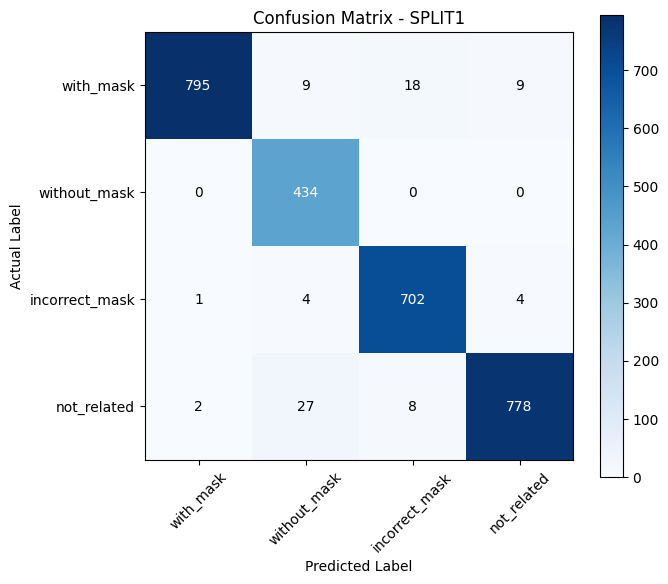


===== TRAINING SPLIT2 =====
Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 86s 7s/step - accuracy: 0.7686 - loss: 0.6176 - val_accuracy: 0.9361 - val_loss: 0.1927
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 723ms/step - accuracy: 0.9436 - loss: 0.1850 - val_accuracy: 0.9700 - val_loss: 0.1056
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 725ms/step - accuracy: 0.9544 - loss: 0.1382 - val_accuracy: 0.9752 - val_loss: 0.0898
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 727ms/step - accuracy: 0.9667 - loss: 0.1115 - val_accuracy: 0.9781 - val_loss: 0.0799
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 719ms/step - accuracy: 0.9696 - loss: 0.0953 - val_accuracy: 0.9798 - val_loss: 0.0727
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 727ms/step - accuracy: 0.9746 - loss: 0.0811 - val_accuracy: 0.9804 - val_loss: 0.0681
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 726ms/step - accuracy: 0.9772 - loss: 0.0749 - val_accuracy: 0.9798 - val_loss: 0.0656
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 724ms/step - accuracy: 0.9773 - loss: 0.0690 - val_a

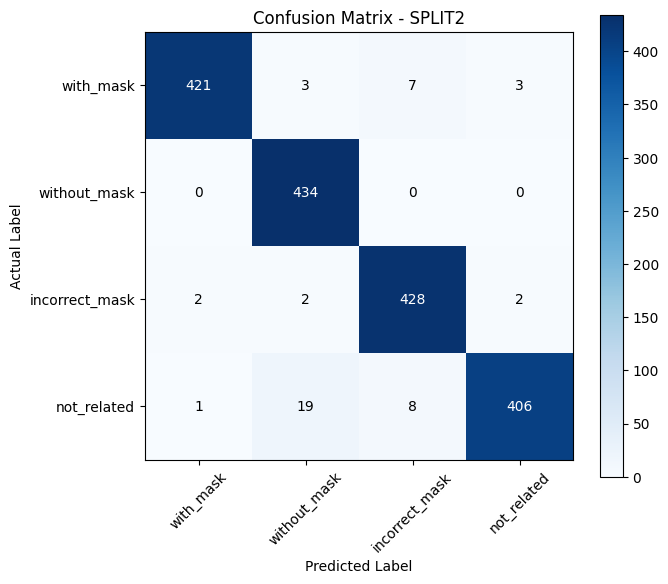


===== TRAINING SPLIT3 =====
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - accuracy: 0.7423 - loss: 0.6868 - val_accuracy: 0.9204 - val_loss: 0.2278
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 682ms/step - accuracy: 0.9333 - loss: 0.2109 - val_accuracy: 0.9537 - val_loss: 0.1569
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 682ms/step - accuracy: 0.9559 - loss: 0.1445 - val_accuracy: 0.9660 - val_loss: 0.1197
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 681ms/step - accuracy: 0.9619 - loss: 0.1242 - val_accuracy: 0.9728 - val_loss: 0.1037
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 681ms/step - accuracy: 0.9681 - loss: 0.1050 - val_accuracy: 0.9735 - val_loss: 0.0999
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 681ms/step - accuracy: 0.9698 - loss: 0.0966 - val_accuracy: 0.9759 - val_loss: 0.0886
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 680ms/step - accuracy: 0.9733 - loss: 0.0856 - val_accuracy: 0.9741 - val_loss: 0.0866
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 684ms/step - accuracy: 0.9775 - loss: 0.0768 - val_a

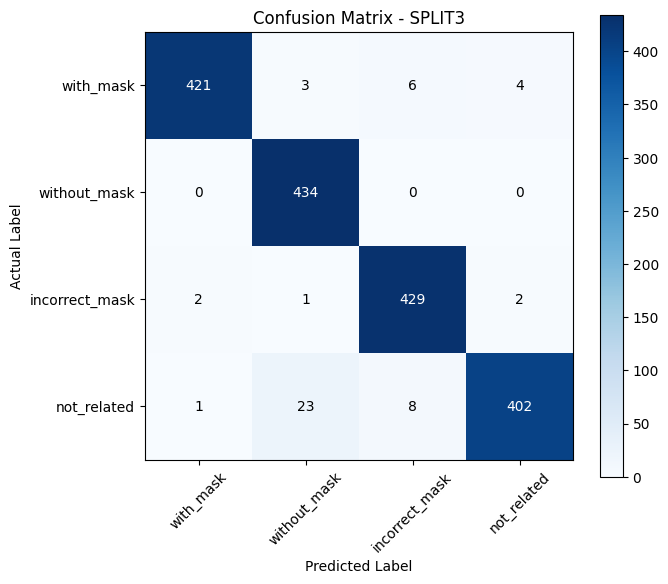

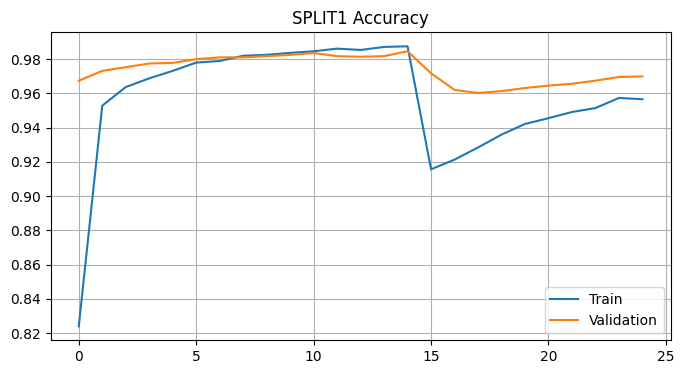

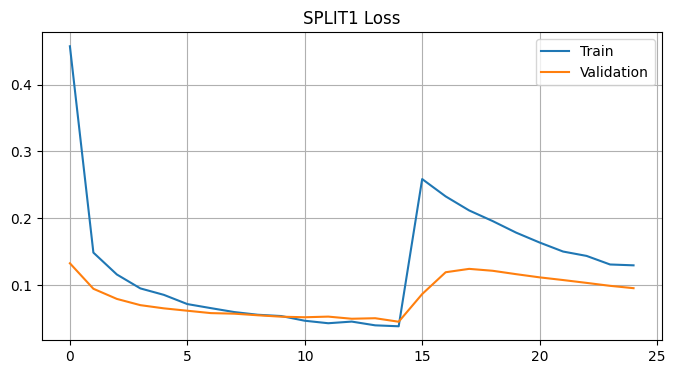

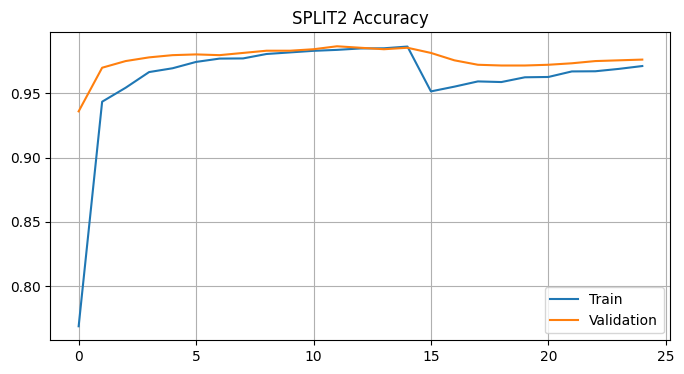

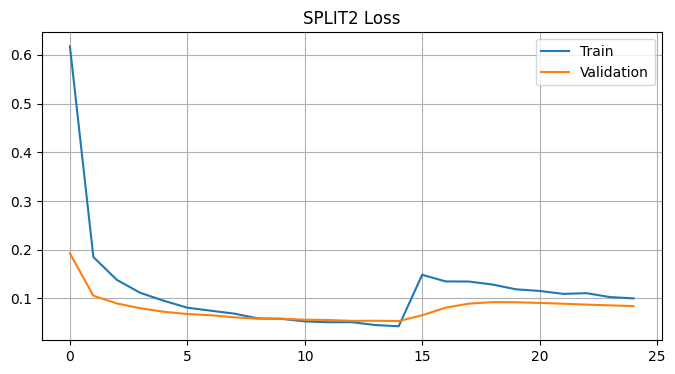

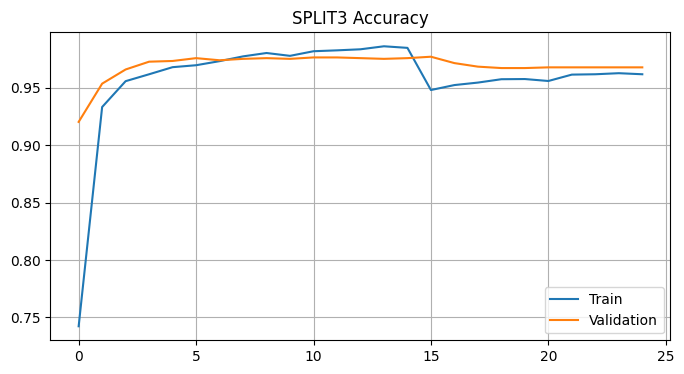

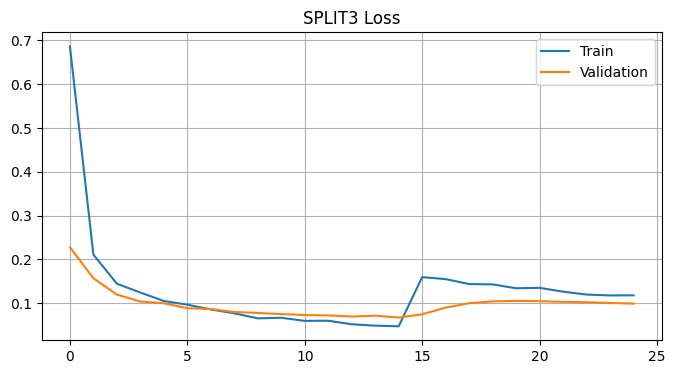

In [ ]:
# ============================================================
# 0. IMPORTS & CONFIGURATION (CANAVAR MOD)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

# PIL uyarı kutularını gizleyerek ekranı temiz tutar
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="PIL")

SEED = 42
TARGET_SIZE = (300, 300) # Modeli B3 yaptığımız için çözünürlüğü 300x300'e çektik
BATCH_SIZE = 1024       # 40GB VRAM'i dolduracak maksimum paket boyutu

tf.random.set_seed(SEED)
np.random.seed(SEED)

CLASSES = [
    "with_mask",
    "without_mask",
    "incorrect_mask",
    "not_related"
]

# ============================================================
# 1. LABEL ENCODING
# ============================================================

le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])

# ============================================================
# 2. CREATE SPLITS
# ============================================================

# --- SPLIT 1: Original distribution ---
train1, temp1 = train_test_split(
    df, test_size=0.30, stratify=df["label_id"], random_state=SEED
)
val1, test1 = train_test_split(
    temp1, test_size=0.50, stratify=temp1["label_id"], random_state=SEED
)

# --- SPLIT 2: Balanced distribution ---
min_count = df["label"].value_counts().min()
df_balanced = (
    df.groupby("label", group_keys=False)
      .sample(n=min_count, random_state=SEED)
      .reset_index(drop=True)
)

train2, temp2 = train_test_split(
    df_balanced, test_size=0.30, stratify=df_balanced["label"], random_state=SEED
)
val2, test2 = train_test_split(
    temp2, test_size=0.50, stratify=temp2["label"], random_state=SEED
)

# --- SPLIT 3: Validation comes from train ---
train3, val3 = train_test_split(
    train2, test_size=0.20, stratify=train2["label"], random_state=SEED
)
test3 = test2.copy()

# ============================================================
# 3. SPLIT STATISTICS
# ============================================================

def print_split_stats(name, train_df, val_df, test_df):
    print(f"\n{name}")
    print("=" * 60)
    print(f"TRAIN : {len(train_df)}\n{train_df['label'].value_counts()}")
    print(f"\nVAL : {len(val_df)}\n{val_df['label'].value_counts()}")
    print(f"\nTEST : {len(test_df)}\n{test_df['label'].value_counts()}")

print_split_stats("SPLIT1", train1, val1, test1)
print_split_stats("SPLIT2", train2, val2, test2)
print_split_stats("SPLIT3", train3, val3, test3)

# ============================================================
# 4 & 5. MODERN TF.DATA PIPELINE (RAM & GPU SÖMÜRÜCÜ MOTOR)
# ============================================================

def load_and_preprocess_image(filepath, label_id, augment=False):
    """Tüm CPU çekirdeklerini kullanarak resmi paralel okur ve işler."""
    raw_img = tf.io.read_file(filepath)
    img = tf.image.decode_image(raw_img, channels=3, expand_animations=False)
    img = tf.image.resize(img, TARGET_SIZE)

    # Veri Artırımı (Augmentation)
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.15)
        img = tf.image.random_contrast(img, lower=0.85, upper=1.15)

    img = preprocess_input(img)
    return img, label_id

def create_modern_dataset(dataframe, shuffle=True, augment=False):
    """A100 ve 84GB RAM'in sınırlarını zorlayan pipeline yapısı."""
    paths = dataframe["filepath"].values
    labels = dataframe["label_id"].values

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=SEED)

    # AUTOTUNE ile tüm CPU çekirdekleri paralel çalışmaya zorlanır
    dataset = dataset.map(
        lambda x, y: load_and_preprocess_image(x, y, augment),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # CACHE: İlk epoch bittikten sonra tüm veri setini 84GB RAM'e kitler.
    # Böylece sonraki epoch'larda Google Drive disk okuma darboğazı sıfırlanır!
    dataset = dataset.cache()

    # Dev Batch Size ile VRAM'i dolduruyoruz
    dataset = dataset.batch(BATCH_SIZE)

    # PREFETCH: GPU matris çarparken CPU sonraki batch'i VRAM'e fırlatır
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

# ============================================================
# 6. MODEL BUILDER (UPGRADED TO EFFICIENTNET-V2-B3)
# ============================================================

def build_model():
    # Modeli B0'dan B3'e yükselttik, canavar kartın hakkını verecek
    base_model = tf.keras.applications.EfficientNetV2B3(
        include_top=False,
        weights="imagenet",
        input_shape=(300, 300, 3)
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ============================================================
# 7. TRAIN FUNCTION (A100 JET MOTORU SÜRÜMÜ)
# ============================================================

def train_model(train_df, val_df, augment_flag, name):
    print(f"\n===== TRAINING {name} =====")

    # Datasetleri modern paralel pipeline ile ayağa kaldırıyoruz
    train_gen = create_modern_dataset(train_df, shuffle=True, augment=augment_flag)
    val_gen = create_modern_dataset(val_df, shuffle=False, augment=False)

    model = build_model()

    # Stage 1: Sadece üst katmanları eğitme
    history1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=15
    )

    # Stage 2: İnce Ayar (Fine Tuning)
    print(f"\n--- Fine Tuning {name} ---")
    base_model = model.layers[0]
    base_model.trainable = True

    # Son 30 katman hariç her yeri dondur
    for layer in base_model.layers[:-10]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(5e-6),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=20
    )

    return model, (history1, history2)

# ============================================================
# 8. EVALUATION
# ============================================================

def evaluate_model(model, test_df, title):
    test_gen = create_modern_dataset(test_df, shuffle=False, augment=False)

    predictions = model.predict(test_gen)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_df["label_id"].values

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7,6))
    plt.imshow(cm, cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {title}")
    plt.colorbar()

    tick_marks = np.arange(len(CLASSES))
    plt.xticks(tick_marks, CLASSES, rotation=45)
    plt.yticks(tick_marks, CLASSES)

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# ============================================================
# 9. TRAIN ALL SPLITS
# ============================================================

# SPLIT1
model1, hist1 = train_model(train1, val1, augment_flag=False, name="SPLIT1")
evaluate_model(model1, test1, "SPLIT1")

# SPLIT2
model2, hist2 = train_model(train2, val2, augment_flag=True, name="SPLIT2")
evaluate_model(model2, test2, "SPLIT2")

# SPLIT3
model3, hist3 = train_model(train3, val3, augment_flag=True, name="SPLIT3")
evaluate_model(model3, test3, "SPLIT3")

# ============================================================
# 10. TRAINING CURVES
# ============================================================

def plot_history(histories, title):
    h1, h2 = histories

    train_acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    train_loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]

    plt.figure(figsize=(8,4))
    plt.plot(train_acc, label="Train")
    plt.plot(val_acc, label="Validation")
    plt.title(f"{title} Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(train_loss, label="Train")
    plt.plot(val_loss, label="Validation")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(hist1, "SPLIT1")
plot_history(hist2, "SPLIT2")
plot_history(hist3, "SPLIT3")

👉 Şablon Kontrolü: SPLIT 3 TEST, SPLIT 2 ile aynı mı?: True

SPLIT1
TRAIN : 14422
label
incorrect_mask    3876
without_mask      3803
not_related       3425
with_mask         3318
Name: count, dtype: int64

VAL : 3090
label
incorrect_mask    830
without_mask      815
not_related       734
with_mask         711
Name: count, dtype: int64

TEST : 3091
label
incorrect_mask    831
without_mask      815
not_related       734
with_mask         711
Name: count, dtype: int64

SPLIT2
TRAIN : 15504
label
with_mask         3876
not_related       3876
without_mask      3876
incorrect_mask    3876
Name: count, dtype: int64

VAL : 3320
label
with_mask         830
incorrect_mask    830
without_mask      830
not_related       830
Name: count, dtype: int64

TEST : 3324
label
incorrect_mask    831
not_related       831
without_mask      831
with_mask         831
Name: count, dtype: int64

SPLIT3
TRAIN : 12776
label
without_mask      3194
incorrect_mask    3194
with_mask         3194
not_related       319

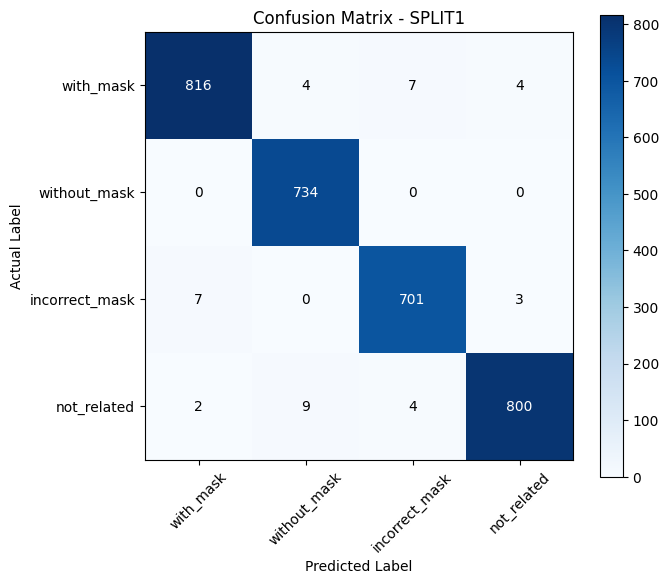


===== TRAINING SPLIT2 =====
Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 183s 9s/step - accuracy: 0.8901 - loss: 0.3352 - val_accuracy: 0.9148 - val_loss: 0.3295
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9678 - loss: 0.1003 - val_accuracy: 0.9545 - val_loss: 0.2027
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9750 - loss: 0.0749 - val_accuracy: 0.9699 - val_loss: 0.1472
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9799 - loss: 0.0589 - val_accuracy: 0.9738 - val_loss: 0.1157
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9831 - loss: 0.0490 - val_accuracy: 0.9774 - val_loss: 0.0998
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9845 - loss: 0.0439 - val_accuracy: 0.9777 - val_loss: 0.0910
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9873 - loss: 0.0385 - val_accuracy: 0.9792 - val_loss: 0.0754
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9889 - loss: 0.0348 - va

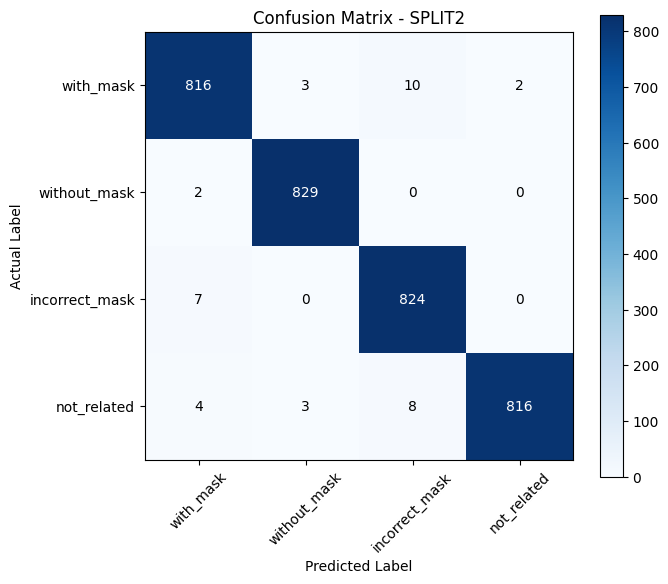


===== TRAINING SPLIT3 =====
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 260s 18s/step - accuracy: 0.8564 - loss: 0.4265 - val_accuracy: 0.9058 - val_loss: 0.3530
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9652 - loss: 0.1124 - val_accuracy: 0.9256 - val_loss: 0.2628
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9718 - loss: 0.0835 - val_accuracy: 0.9564 - val_loss: 0.1701
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9767 - loss: 0.0671 - val_accuracy: 0.9696 - val_loss: 0.1364
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9801 - loss: 0.0598 - val_accuracy: 0.9758 - val_loss: 0.1099
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9823 - loss: 0.0545 - val_accuracy: 0.9773 - val_loss: 0.0924
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9850 - loss: 0.0476 - val_accuracy: 0.9831 - val_loss: 0.0816
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9859 - loss: 0.0403 - v

3/4 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 5s/step

Classification Report:
                precision    recall  f1-score   support

     with_mask       0.99      0.98      0.98       831
  without_mask       0.99      0.99      0.99       831
incorrect_mask       0.98      0.99      0.99       831
   not_related       0.99      0.98      0.98       831

      accuracy                           0.99      3324
     macro avg       0.99      0.99      0.99      3324
  weighted avg       0.99      0.99      0.99      3324



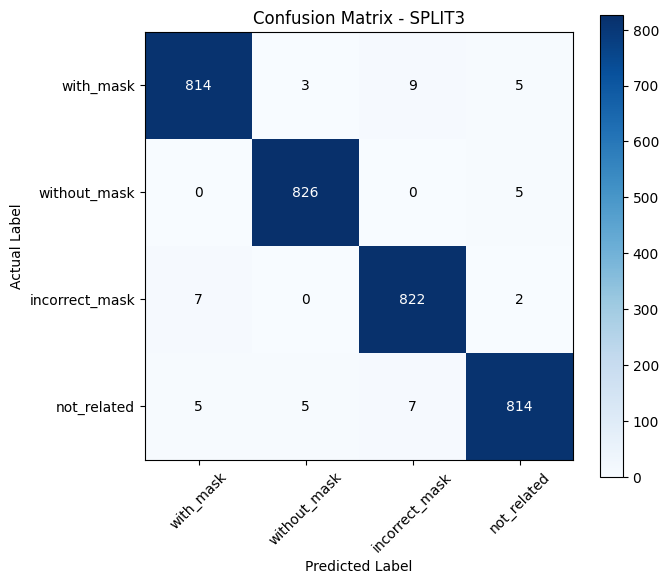

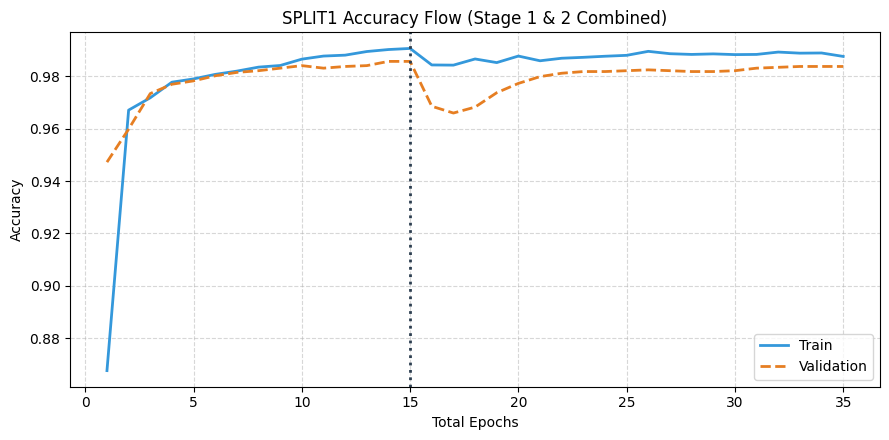

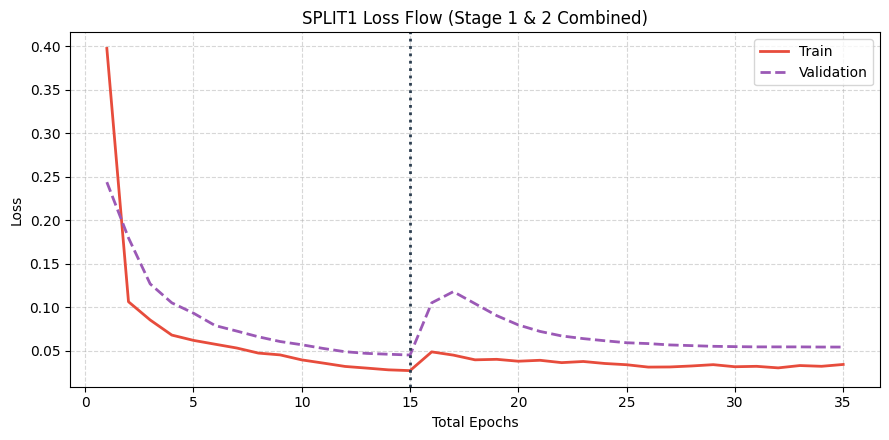

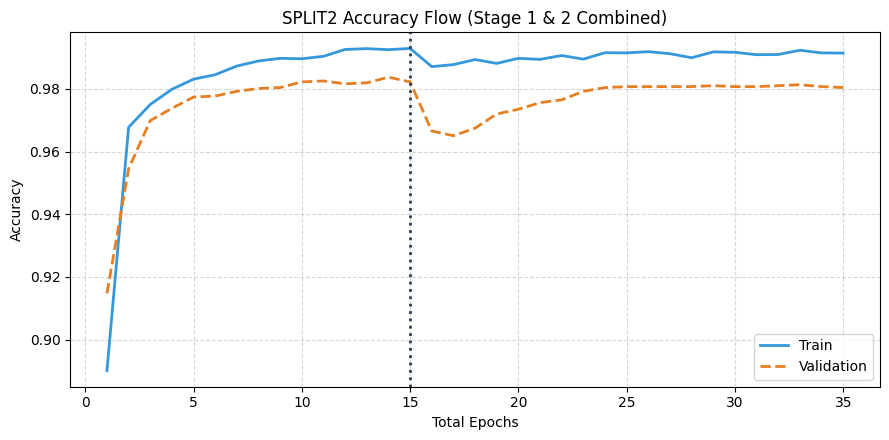

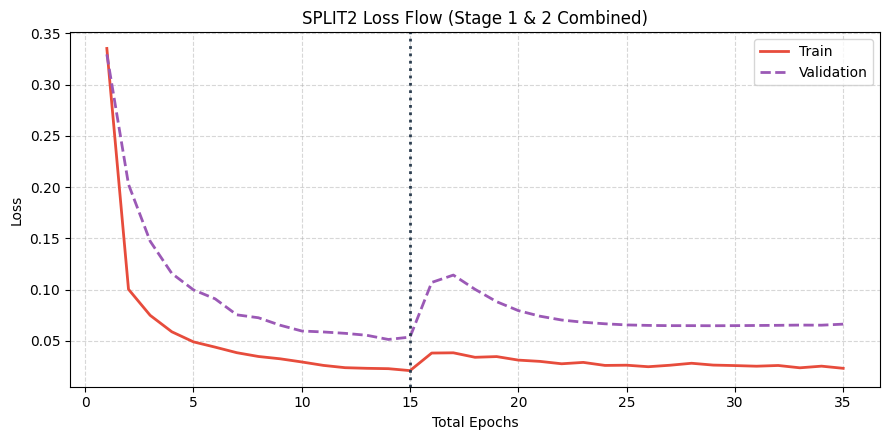

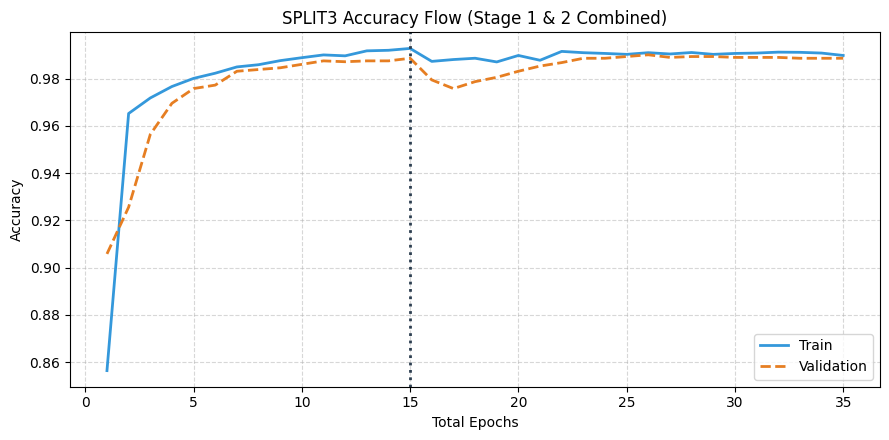

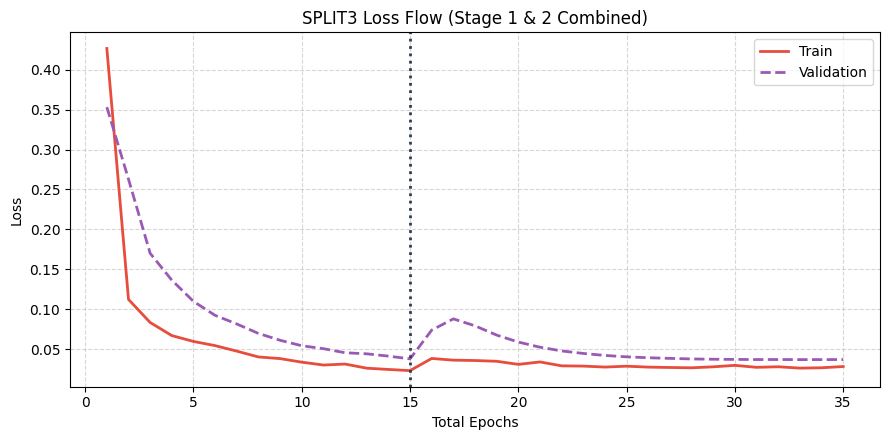

In [ ]:
# ============================================================
# 0. IMPORTS & CONFIGURATION (CANAVAR MOD - ULTIMATE)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

SEED = 42
TARGET_SIZE = (300, 300) # Modeli B3 yaptığımız için çözünürlüğü 300x300'e çektik
BATCH_SIZE = 1024       # 40GB VRAM'i dolduracak maksimum paket boyutu

tf.random.set_seed(SEED)
np.random.seed(SEED)

CLASSES = [
    "with_mask",
    "without_mask",
    "incorrect_mask",
    "not_related"
]

# ============================================================
# 1. LABEL ENCODING
# ============================================================

le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])

# ============================================================
# 2. CREATE SPLITS (AUGMENTED UPSAMPLING & HOCA ŞABLONU)
# ============================================================

def balance_by_upsampling_paths(dataframe, target_per_class):
    """
    Sınıfları kırpmaz. Az olan sınıfların dosya yollarını hedefe kadar kopyalar.
    Bu kopyalar tf.data pipeline'ında otomatik olarak RASTGELE AUGMENT edilecektir!
    """
    chunks = []
    for class_name in dataframe["label"].unique():
        class_df = dataframe[dataframe["label"] == class_name]
        if len(class_df) >= target_per_class:
            # En büyük sınıftan tam hedef kadar (3876) alıyoruz
            chunks.append(class_df.sample(target_per_class, random_state=SEED))
        else:
            # Az olan sınıfları (Örn: 3318 olanı) 3876'ya tamamlamak için eksik miktar kadar kopyalıyoruz
            chunks.append(class_df.sample(target_per_class, replace=True, random_state=SEED))
    return pd.concat(chunks).sample(frac=1, random_state=SEED).reset_index(drop=True)

# --- SPLIT 1: Original Distribution (%70, %15, %15) ---
train1, temp1 = train_test_split(
    df, test_size=0.30, stratify=df["label_id"], random_state=SEED
)
val1, test1 = train_test_split(
    temp1, test_size=0.50, stratify=temp1["label_id"], random_state=SEED
)

# --- SPLIT 2: Balanced + Augmented Distribution ---
# Buradaki target_per_class değerini en büyük sınıfın (3876) sayısına kilitliyoruz!
train2 = balance_by_upsampling_paths(train1, target_per_class=3876)
val2 = balance_by_upsampling_paths(val1, target_per_class=830)   # Şemadaki Val hedefi sınıf başına ~830
test2 = balance_by_upsampling_paths(test1, target_per_class=831) # Şemadaki Test hedefi sınıf başına ~831


# --- SPLIT 3: VAL carved from TRAIN, TEST unchanged ---
# TEST seti Split 2 ile tamamen aynı kalıyor (Birebir şema isteridir)
test3 = test2.copy()

# Split 2'nin 15.504 resimlik dengelenmiş Train setinden, sınıf başına tam 682'şer adet VAL koparıyoruz
train3_chunks = []
val3_chunks = []

for class_name in train2["label"].unique():
    class_df = train2[train2["label"] == class_name]
    # Sınıf başına 3876 resmin 682'si VAL'e, kalan 3194'ü TRAIN'e ayrılıyor
    c_train, c_val = train_test_split(
        class_df, test_size=(682 / 3876), random_state=SEED
    )
    train3_chunks.append(c_train)
    val3_chunks.append(c_val)

train3 = pd.concat(train3_chunks).sample(frac=1, random_state=SEED).reset_index(drop=True)
val3 = pd.concat(val3_chunks).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("👉 Şablon Kontrolü: SPLIT 3 TEST, SPLIT 2 ile aynı mı?:", test3.equals(test2))

# ============================================================
# 3. SPLIT STATISTICS
# ============================================================

def print_split_stats(name, train_df, val_df, test_df):
    print(f"\n{name}")
    print("=" * 60)
    print(f"TRAIN : {len(train_df)}\n{train_df['label'].value_counts()}")
    print(f"\nVAL : {len(val_df)}\n{val_df['label'].value_counts()}")
    print(f"\nTEST : {len(test_df)}\n{test_df['label'].value_counts()}")

print_split_stats("SPLIT1", train1, val1, test1)
print_split_stats("SPLIT2", train2, val2, test2)
print_split_stats("SPLIT3", train3, val3, test3)

# ============================================================
# 4 & 5. MODERN TF.DATA PIPELINE (RAM & GPU SÖMÜRÜCÜ MOTOR)
# ============================================================

def load_and_preprocess_image(filepath, label_id, augment=False):
    """Tüm CPU çekirdeklerini kullanarak resmi paralel okur ve işler."""
    raw_img = tf.io.read_file(filepath)
    img = tf.image.decode_image(raw_img, channels=3, expand_animations=False)
    img = tf.image.resize(img, TARGET_SIZE)

    # Veri Artırımı (Augmentation)
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.15)
        img = tf.image.random_contrast(img, lower=0.85, upper=1.15)

    img = preprocess_input(img)
    return img, label_id

def create_modern_dataset(dataframe, shuffle=True, augment=False):
    """A100 ve 84GB RAM'in sınırlarını zorlayan pipeline yapısı."""
    paths = dataframe["filepath"].values
    labels = dataframe["label_id"].values

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=SEED)

    # AUTOTUNE ile tüm CPU çekirdekleri paralel çalışmaya zorlanır
    dataset = dataset.map(
        lambda x, y: load_and_preprocess_image(x, y, augment),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # CACHE: İlk epoch bittikten sonra tüm veri setini 84GB RAM'e kitler.
    dataset = dataset.cache()

    # Dev Batch Size ile VRAM'i dolduruyoruz
    dataset = dataset.batch(BATCH_SIZE)

    # PREFETCH: GPU matris çarparken CPU sonraki batch'i VRAM'e fırlatır
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

# ============================================================
# 6. MODEL BUILDER (UPGRADED WITH SHOCK ABSORBERS)
# ============================================================

def build_model():
    # Modeli B0'dan B3'e yükselttik, canavar kartın hakkını verecek
    base_model = tf.keras.applications.EfficientNetV2B3(
        include_top=False,
        weights="imagenet",
        input_shape=(300, 300, 3)
    )
    base_model.trainable = False

    # Araya yerleştirdiğimiz BatchNormalization ve Dropout,
    # modelin esnekliğini korurken fine-tuning şokunu emen muhakeme odasıdır.
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.BatchNormalization(), # Stage 2 için gradyan amortisörü
        tf.keras.layers.Dropout(0.4),          # Ezberlemeyi (overfitting) engelleyen filtre
        tf.keras.layers.Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ============================================================
# 7. TRAIN FUNCTION (A100 JET MOTORU + COSINE DECAY SÜRÜMÜ)
# ============================================================

def train_model(train_df, val_df, augment_flag, name):
    print(f"\n===== TRAINING {name} =====")

    # Datasetleri modern paralel pipeline ile ayağa kaldırıyoruz
    train_gen = create_modern_dataset(train_df, shuffle=True, augment=augment_flag)
    val_gen = create_modern_dataset(val_df, shuffle=False, augment=False)

    model = build_model()

    # Stage 1: Sadece üst katmanları eğitme (Oryantasyon Aşaması)
    history1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=15
    )

    # Stage 2: İnce Ayar (Fine Tuning)
    print(f"\n--- Fine Tuning {name} ---")
    base_model = model.layers[0]
    base_model.trainable = True

    # Yıkıcı Unutmayı engellemek için sadece son 10 katmanı esnetiyoruz
    for layer in base_model.layers[:-10]:
        layer.trainable = False

    # COSINE DECAY INTEGRATION:
    # Öğrenme hızını fine-tuning boyunca tatlı bir dalgayla sıfıra eritiyoruz.
    # Epoch sayısını 20 tutarak modelin o "V" kırılmasından sonra tamamen şahlanmasını sağlıyoruz.
    stage2_epochs = 20
    decay_steps = stage2_epochs * len(train_gen)

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=5e-6,
        decay_steps=decay_steps
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=stage2_epochs
    )

    return model, (history1, history2)

# ============================================================
# 8. EVALUATION
# ============================================================

def evaluate_model(model, test_df, title):
    test_gen = create_modern_dataset(test_df, shuffle=False, augment=False)

    predictions = model.predict(test_gen)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_df["label_id"].values

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7,6))
    plt.imshow(cm, cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {title}")
    plt.colorbar()

    tick_marks = np.arange(len(CLASSES))
    plt.xticks(tick_marks, CLASSES, rotation=45)
    plt.yticks(tick_marks, CLASSES)

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# ============================================================
# 9. TRAIN ALL SPLITS
# ============================================================

# SPLIT1
model1, hist1 = train_model(train1, val1, augment_flag=False, name="SPLIT1")
evaluate_model(model1, test1, "SPLIT1")

# SPLIT2
model2, hist2 = train_model(train2, val2, augment_flag=True, name="SPLIT2")
evaluate_model(model2, test2, "SPLIT2")

# SPLIT3
model3, hist3 = train_model(train3, val3, augment_flag=True, name="SPLIT3")
evaluate_model(model3, test3, "SPLIT3")

# ============================================================
# 10. TRAINING CURVES (ADVANCED ALIGNED AKIŞ)
# ============================================================

def plot_history(histories, title):
    h1, h2 = histories

    # İki aşamayı tam zamansal akışına göre uç uca ekliyoruz
    train_acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    train_loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]

    stage1_end = len(h1.history["accuracy"])

    # --- ACCURACY GRAFİĞİ ---
    plt.figure(figsize=(9,4.5))
    plt.plot(range(1, len(train_acc) + 1), train_acc, label="Train", color="#3498db", linewidth=2)
    plt.plot(range(1, len(val_acc) + 1), val_acc, label="Validation", color="#e67e22", linewidth=2, linestyle="--")
    plt.axvline(x=stage1_end, color='#2c3e50', linestyle=':', linewidth=2)
    plt.title(f"{title} Accuracy Flow (Stage 1 & 2 Combined)")
    plt.xlabel("Total Epochs")
    plt.ylabel("Accuracy")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- LOSS GRAFİĞİ ---
    plt.figure(figsize=(9,4.5))
    plt.plot(range(1, len(train_loss) + 1), train_loss, label="Train", color="#e74c3c", linewidth=2)
    plt.plot(range(1, len(val_loss) + 1), val_loss, label="Validation", color="#9b59b6", linewidth=2, linestyle="--")
    plt.axvline(x=stage1_end, color='#2c3e50', linestyle=':', linewidth=2)
    plt.title(f"{title} Loss Flow (Stage 1 & 2 Combined)")
    plt.xlabel("Total Epochs")
    plt.ylabel("Loss")
    plt.legend(loc="upper right")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_history(hist1, "SPLIT1")
plot_history(hist2, "SPLIT2")
plot_history(hist3, "SPLIT3")

🚀 GPU tam kapasite tahmine başlıyor...
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step

📊 Toplam Hatalı Tahmin Sayısı: 40
                                                filepath           label  \
20153  /content/drive/MyDrive/dataset/FMD_DATASET/wit...    without_mask   
3576   /content/drive/MyDrive/dataset/FMD_DATASET/wit...    without_mask   
1151   /content/drive/MyDrive/dataset/FMD_DATASET/wit...       with_mask   
1135   /content/drive/MyDrive/dataset/FMD_DATASET/wit...       with_mask   
19365  /content/drive/MyDrive/dataset/FMD_DATASET/wit...    without_mask   
19416  /content/drive/MyDrive/dataset/FMD_DATASET/wit...    without_mask   
7385   /content/drive/MyDrive/dataset/FMD_DATASET/inc...  incorrect_mask   
3575   /content/drive/MyDrive/dataset/FMD_DATASET/wit...    without_mask   
7924   /content/drive/MyDrive/dataset/FMD_DATASET/inc...  incorrect_mask   
17630  /content/drive/MyDrive/dataset/face_data/incor...  incorrect_mask   

      predicted_label  
20153  incorrect_mask  
3576

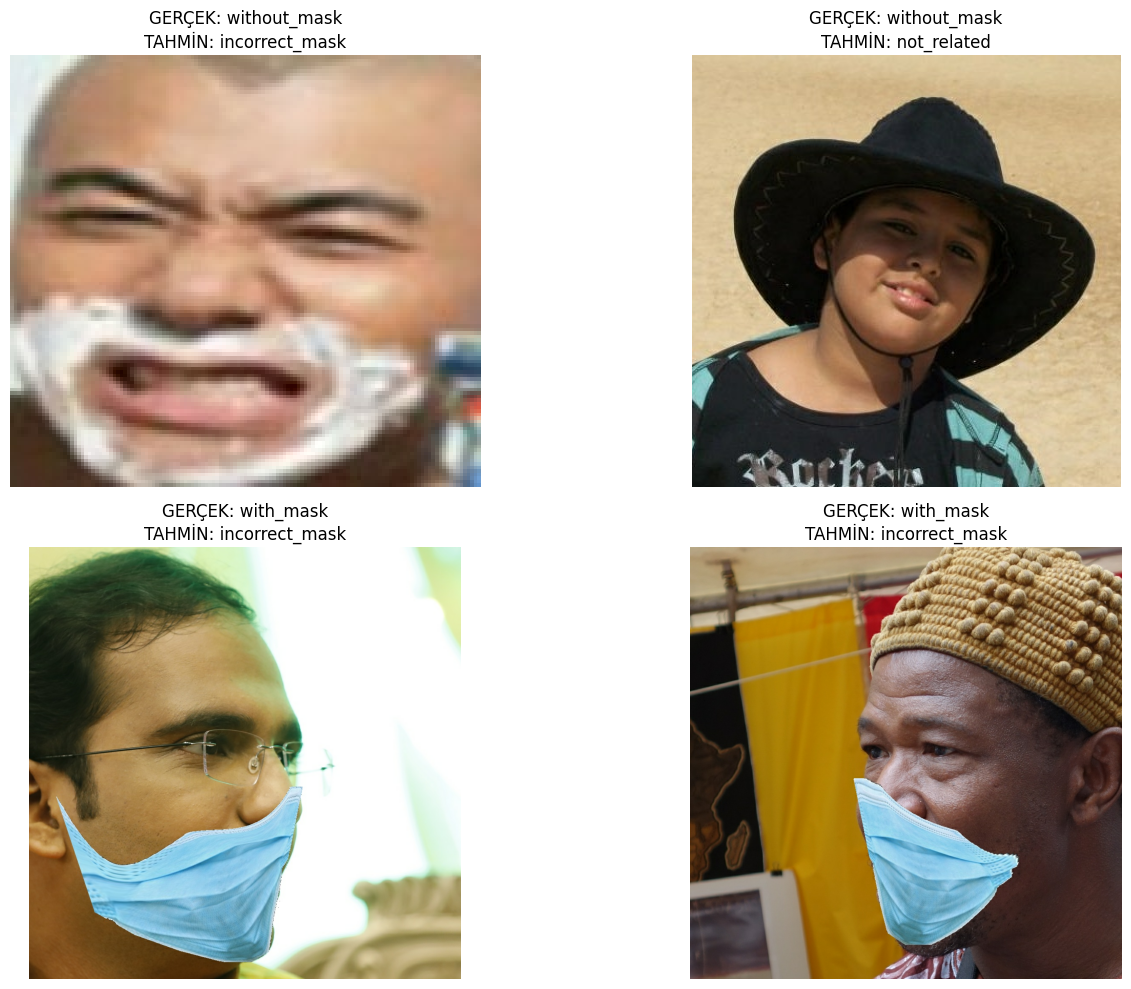

In [ ]:
# ============================================================
# ULTRA OPTİMİZE - TÜM DONANIMI BAĞIRTAN ANALİZ KODU
# ============================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. PARAMETRELERİ AYARLA (Hangi split'i inceleyeceksen onu yaz)
current_df = test1.copy()  # SPLIT1 Test verisi

# 2. TF.DATA PIPELINE: CPU ÇEKİRDEKLERİNİ PARALEL ATEŞLE
def load_and_preprocess(filepath, label_id):
    img_raw = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img_raw, channels=3) # Veya decode_png (verine göre)
    img = tf.image.resize(img, (300, 300))          # Yeni çözünürlüğün 300x300
    # Model içindeki preprocess_input katmanını veya fonksiyonunu buraya bağla:
    img = tf.keras.applications.efficientnet_v2.preprocess_input(img)
    return img, label_id

# Dataset'i oluştur ve tüm CPU çekirdeklerine (AUTOTUNE) dağıt
path_ds = tf.data.Dataset.from_tensor_slices(current_df["filepath"].values)
label_ds = tf.data.Dataset.from_tensor_slices(current_df["label_id"].values)
dataset = tf.data.Dataset.zip((path_ds, label_ds))

# Sıralı tahmin yapacağımız için shuffle YOK, ama paralel yükleme VAR
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(1024).prefetch(tf.data.AUTOTUNE) # Dev batch boyutu!

# 3. GPU BOMBALAMASI (Inference)
print("🚀 GPU tam kapasite tahmine başlıyor...")
predictions = model1.predict(dataset) # A100 burada VRAM'i doldurup saniyede bitirir
y_pred = np.argmax(predictions, axis=1)
y_true = current_df["label_id"].values

# 4. VEKTÖREL HIZDA HATALARI BULMA (Pandas iterrows ameleliği bitti)
current_df["predicted_id"] = y_pred
current_df["predicted_label"] = le.inverse_transform(y_pred)
errors_df = current_df[current_df["label_id"] != current_df["predicted_id"]]

print(f"\n📊 Toplam Hatalı Tahmin Sayısı: {len(errors_df)}")
print("="*60)
print(errors_df[["filepath", "label", "predicted_label"]].head(10))
print("="*60)

# 5. MATPLOTLIB IŞIK HIZINDA ÇİZİM
if len(errors_df) > 0:
    plt.figure(figsize=(15, 10))
    for i, (idx, row) in enumerate(errors_df.head(4).iterrows()):
        # Burada tf.io kullanarak yine hızlıca okuyoruz
        img_raw = tf.io.read_file(row['filepath'])
        img = tf.image.decode_image(img_raw, channels=3).numpy()

        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.title(f"GERÇEK: {row['label']}\nTAHMİN: {row['predicted_label']}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

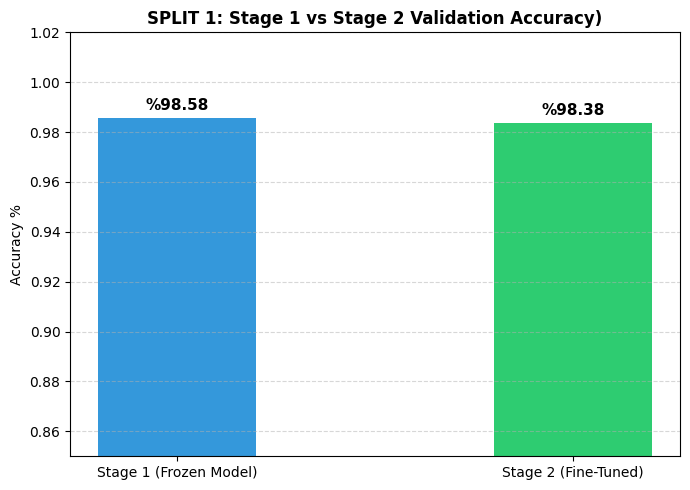

In [ ]:
# ============================================================
# SIFIRDAN EĞİTMEDEN LOGLARDAN STAGE KIYASLAMA GRAFİĞİ
# ============================================================
import matplotlib.pyplot as plt

# hist1 içinden Stage 1 ve Stage 2 geçmişlerini ayırıyoruz
h1, h2 = hist1

# Stage 1'in son epoch'undaki (15. epoch) validation başarısı
stage1_val_acc = h1.history["val_accuracy"][-1]

# Stage 2'in son epoch'undaki (10. epoch) validation başarısı
stage2_val_acc = h2.history["val_accuracy"][-1]

# Grafiği çizdir
plt.figure(figsize=(7, 5))
stages = ['Stage 1 (Frozen Model)', 'Stage 2 (Fine-Tuned)']
accuracies = [stage1_val_acc, stage2_val_acc]

bars = plt.bar(stages, accuracies, color=['#3498db', '#2ecc71'], width=0.4)

# Barların üzerine net yüzde değerlerini yazalım
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"%{yval*100:.2f}",
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title("SPLIT 1: Stage 1 vs Stage 2 Validation Accuracy)", fontsize=12, fontweight='bold')
plt.ylabel('Accuracy %', fontsize=10)
plt.ylim(0.85, 1.02) # Farkı net görmek için alt sınırı 0.85 yaptık
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

🎯 MODELLERİN HİÇ GÖRMEDİĞİ TEST SETLERİ İLE SINAVI BAŞLIYOR

🔥 [TEST REPORT] SPLIT 1 - Orijinal Dağılım Test Sonuçları:
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

Classification Report:
                precision    recall  f1-score   support

     with_mask       0.99      0.98      0.99       831
  without_mask       0.98      1.00      0.99       734
incorrect_mask       0.98      0.99      0.99       711
   not_related       0.99      0.98      0.99       815

      accuracy                           0.99      3091
     macro avg       0.99      0.99      0.99      3091
  weighted avg       0.99      0.99      0.99      3091



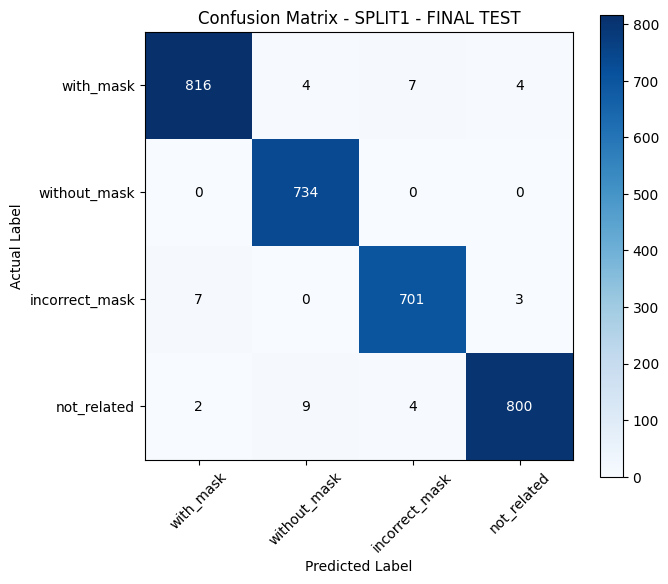


🔥 [TEST REPORT] SPLIT 2 - Dengelenmiş Dağılım Test Sonuçları:
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

Classification Report:
                precision    recall  f1-score   support

     with_mask       0.98      0.98      0.98       831
  without_mask       0.99      1.00      1.00       831
incorrect_mask       0.98      0.99      0.99       831
   not_related       1.00      0.98      0.99       831

      accuracy                           0.99      3324
     macro avg       0.99      0.99      0.99      3324
  weighted avg       0.99      0.99      0.99      3324



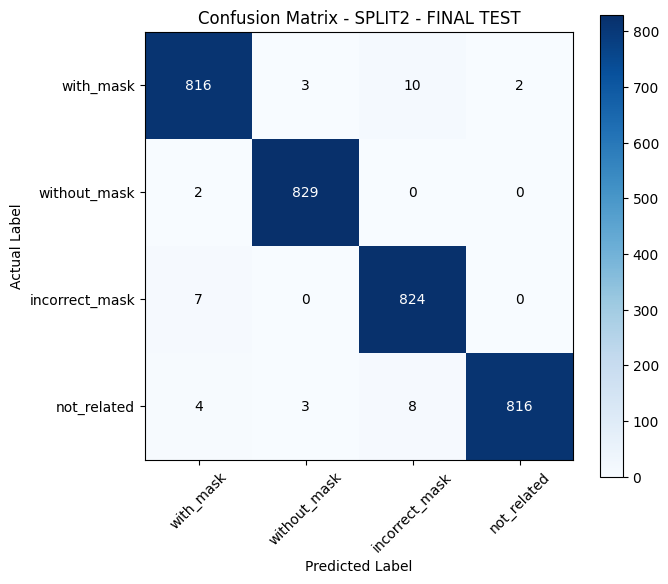


🔥 [TEST REPORT] SPLIT 3 - Train'den Ayrılan Dağılım Test Sonuçları:
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

Classification Report:
                precision    recall  f1-score   support

     with_mask       0.99      0.98      0.98       831
  without_mask       0.99      0.99      0.99       831
incorrect_mask       0.98      0.99      0.99       831
   not_related       0.99      0.98      0.98       831

      accuracy                           0.99      3324
     macro avg       0.99      0.99      0.99      3324
  weighted avg       0.99      0.99      0.99      3324



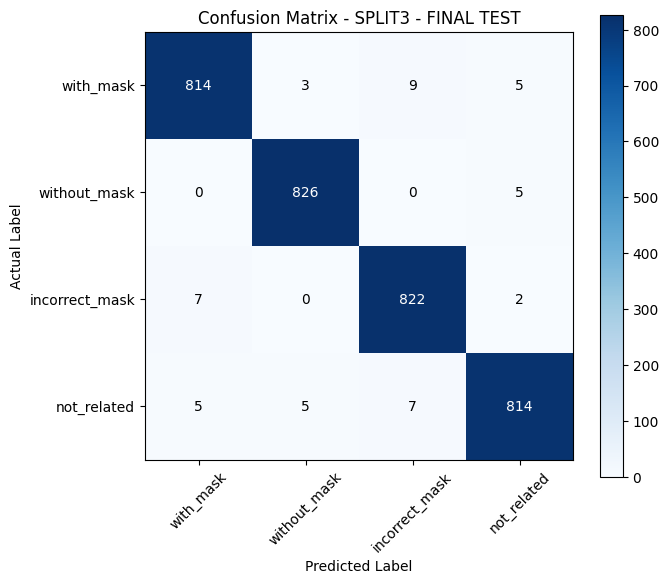

In [ ]:
# ============================================================
# 11. NIHAI TEST SETİ SINAVI (REAL-WORLD TEST)
# ============================================================

print("============================================================")
print("🎯 MODELLERİN HİÇ GÖRMEDİĞİ TEST SETLERİ İLE SINAVI BAŞLIYOR")
print("============================================================")

# --- SPLIT 1 TESTİ ---
print("\n🔥 [TEST REPORT] SPLIT 1 - Orijinal Dağılım Test Sonuçları:")
evaluate_model(model1, test1, "SPLIT1 - FINAL TEST")

# --- SPLIT 2 TESTİ ---
print("\n🔥 [TEST REPORT] SPLIT 2 - Dengelenmiş Dağılım Test Sonuçları:")
evaluate_model(model2, test2, "SPLIT2 - FINAL TEST")

# --- SPLIT 3 TESTİ ---
print("\n🔥 [TEST REPORT] SPLIT 3 - Train'den Ayrılan Dağılım Test Sonuçları:")
evaluate_model(model3, test3, "SPLIT3 - FINAL TEST")

📊 Preparing presentation graphics for: SPLIT 1...
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


/tmp/ipykernel_37975/2606360901.py:98: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=4.0)
/tmp/ipykernel_37975/2606360901.py:98: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=4.0)
/tmp/ipykernel_37975/2606360901.py:98: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=4.0)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from 

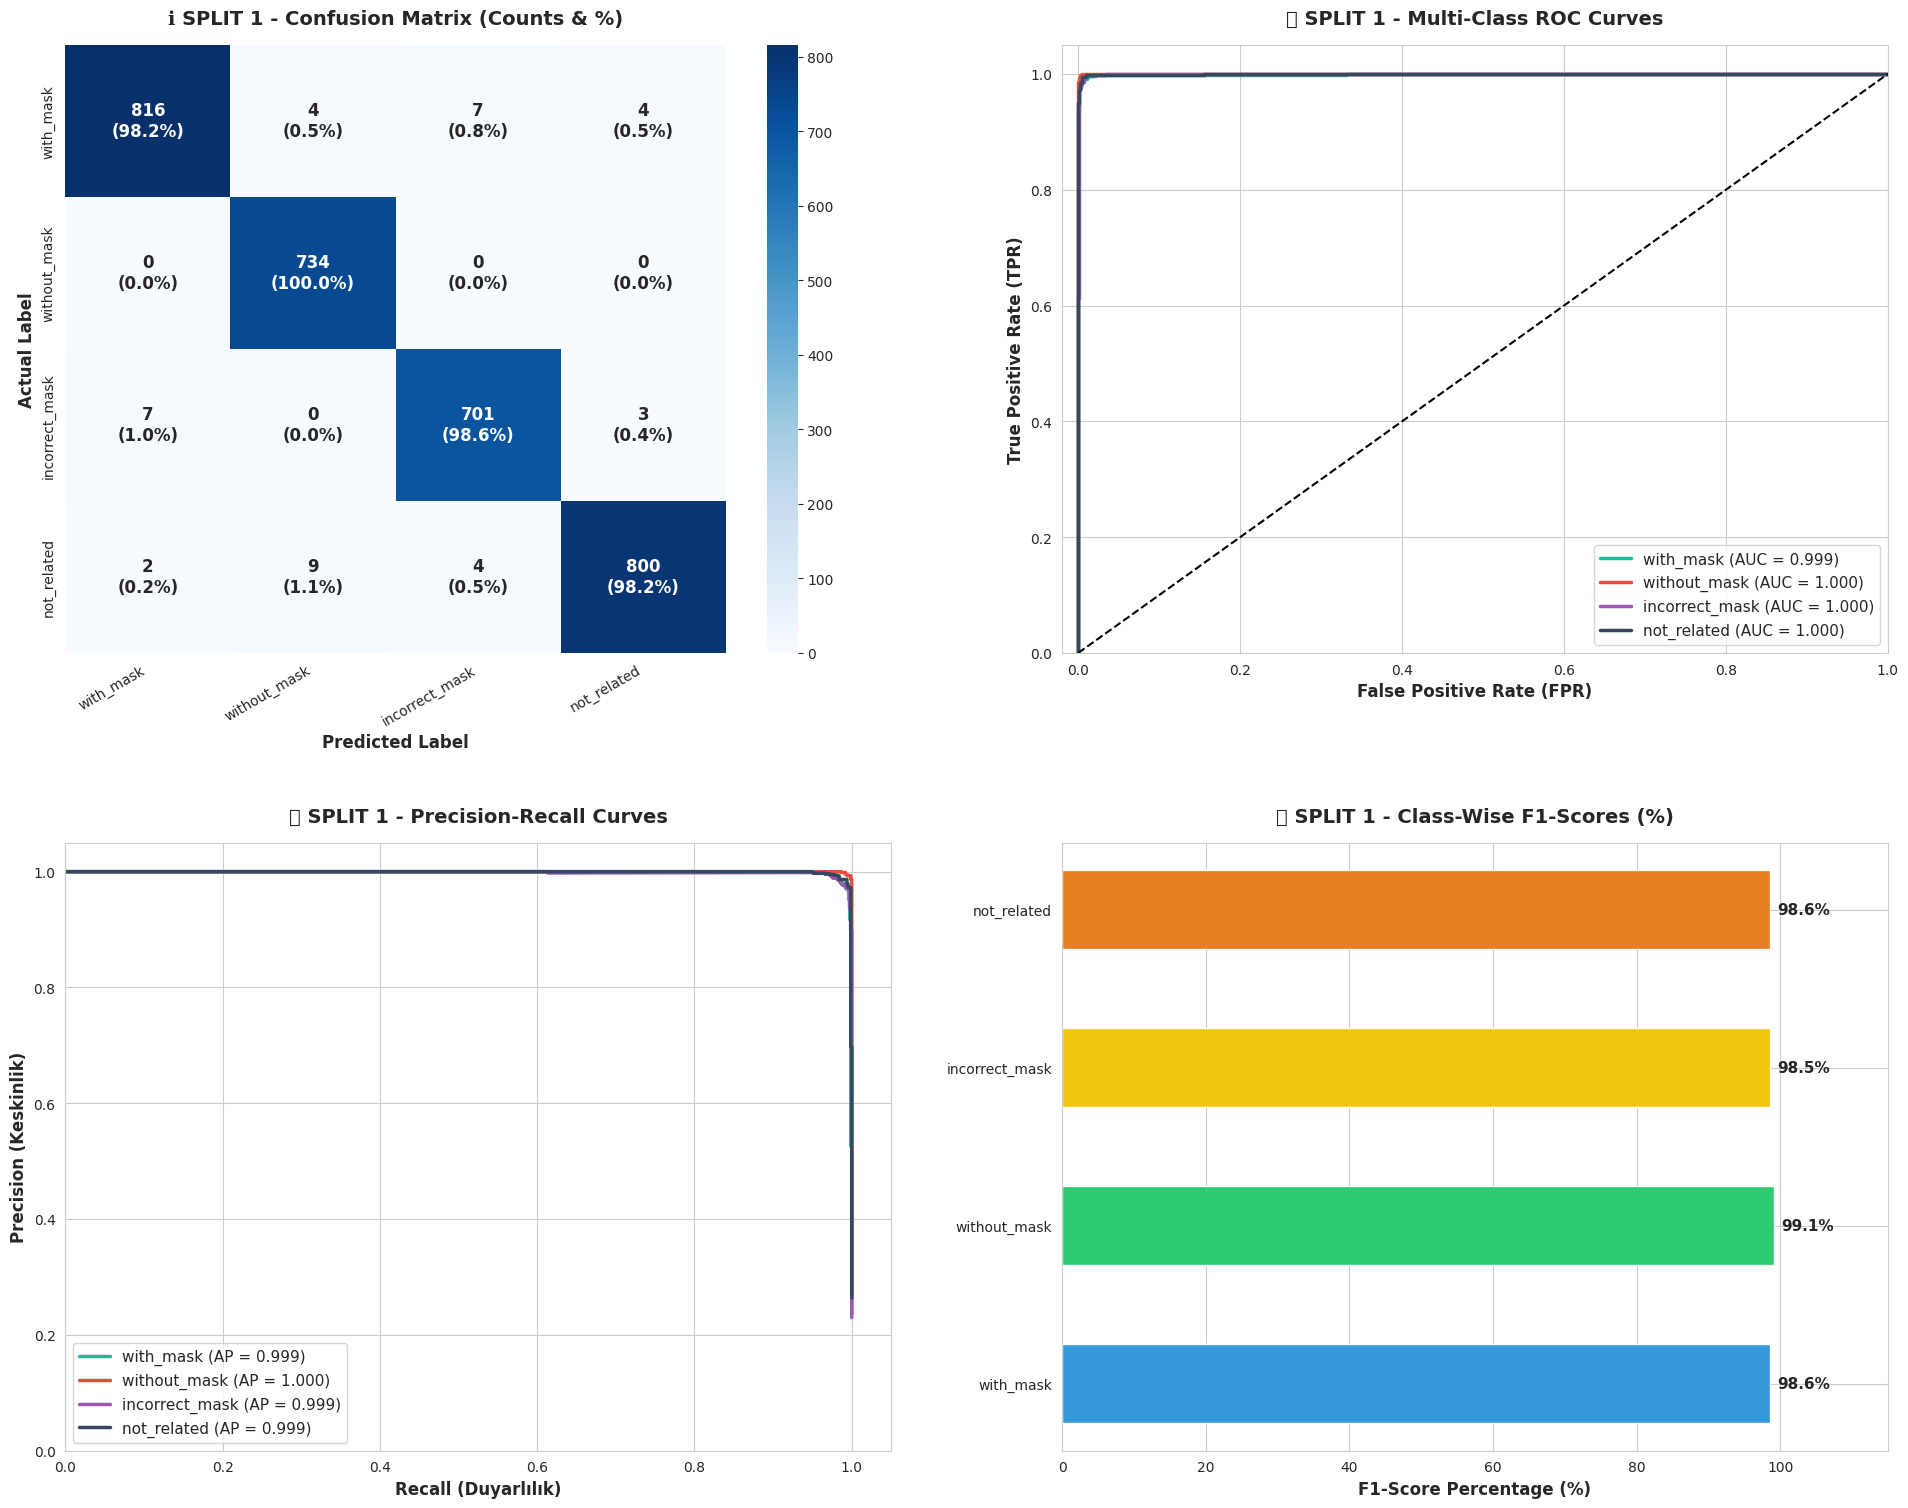

📊 Preparing presentation graphics for: SPLIT 2...
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step


/tmp/ipykernel_37975/2606360901.py:98: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=4.0)
/tmp/ipykernel_37975/2606360901.py:98: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=4.0)
/tmp/ipykernel_37975/2606360901.py:98: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=4.0)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from 

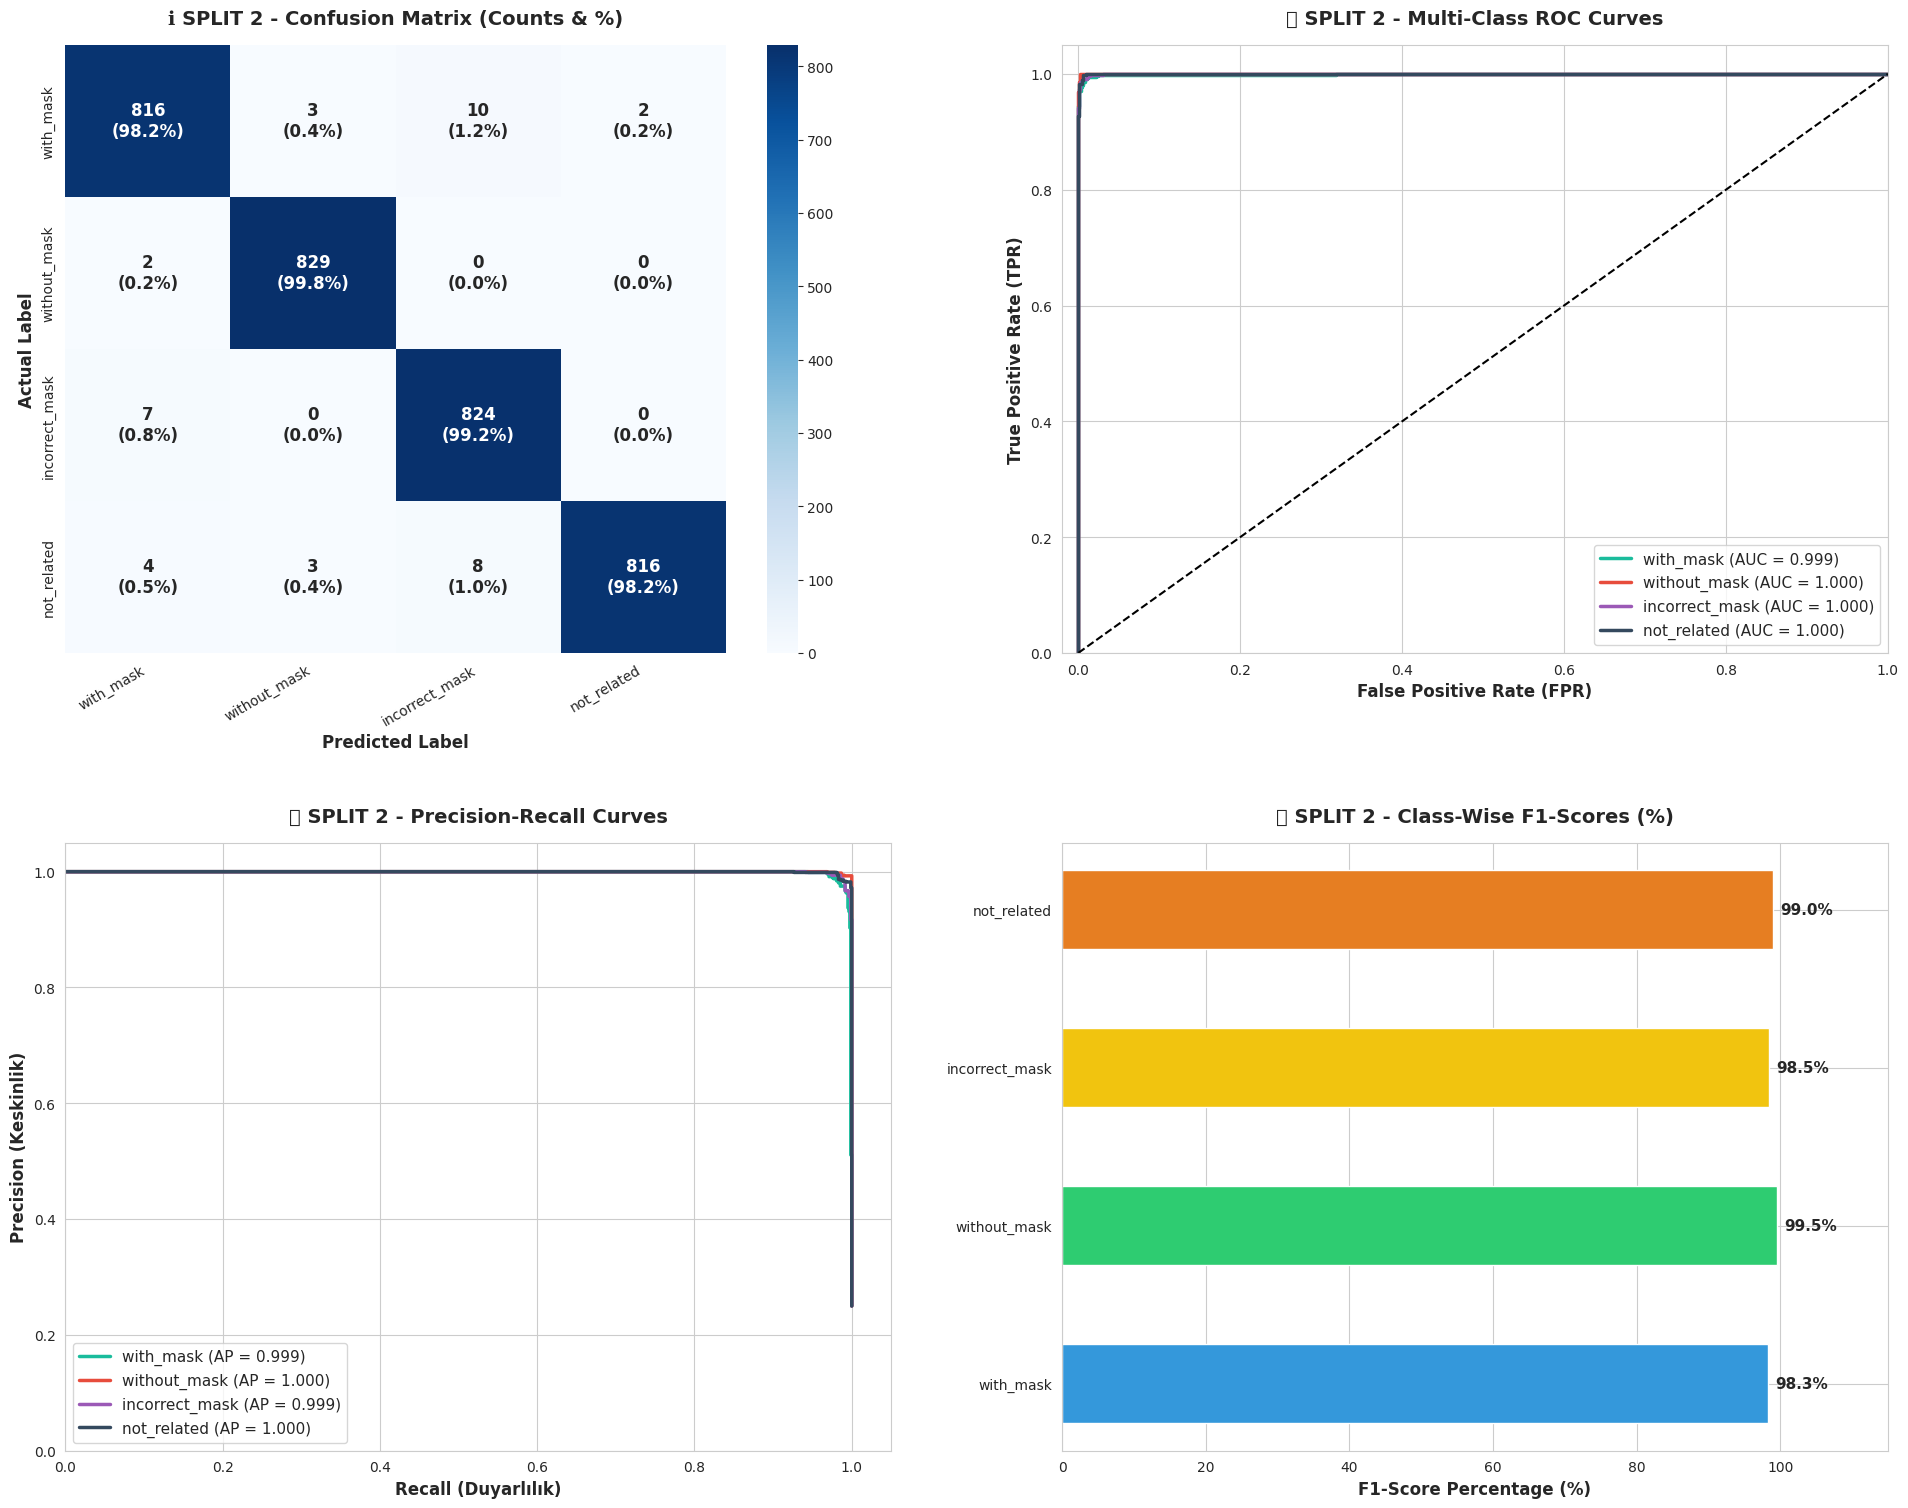

📊 Preparing presentation graphics for: SPLIT 3...
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step


/tmp/ipykernel_37975/2606360901.py:98: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=4.0)
/tmp/ipykernel_37975/2606360901.py:98: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=4.0)
/tmp/ipykernel_37975/2606360901.py:98: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=4.0)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from 

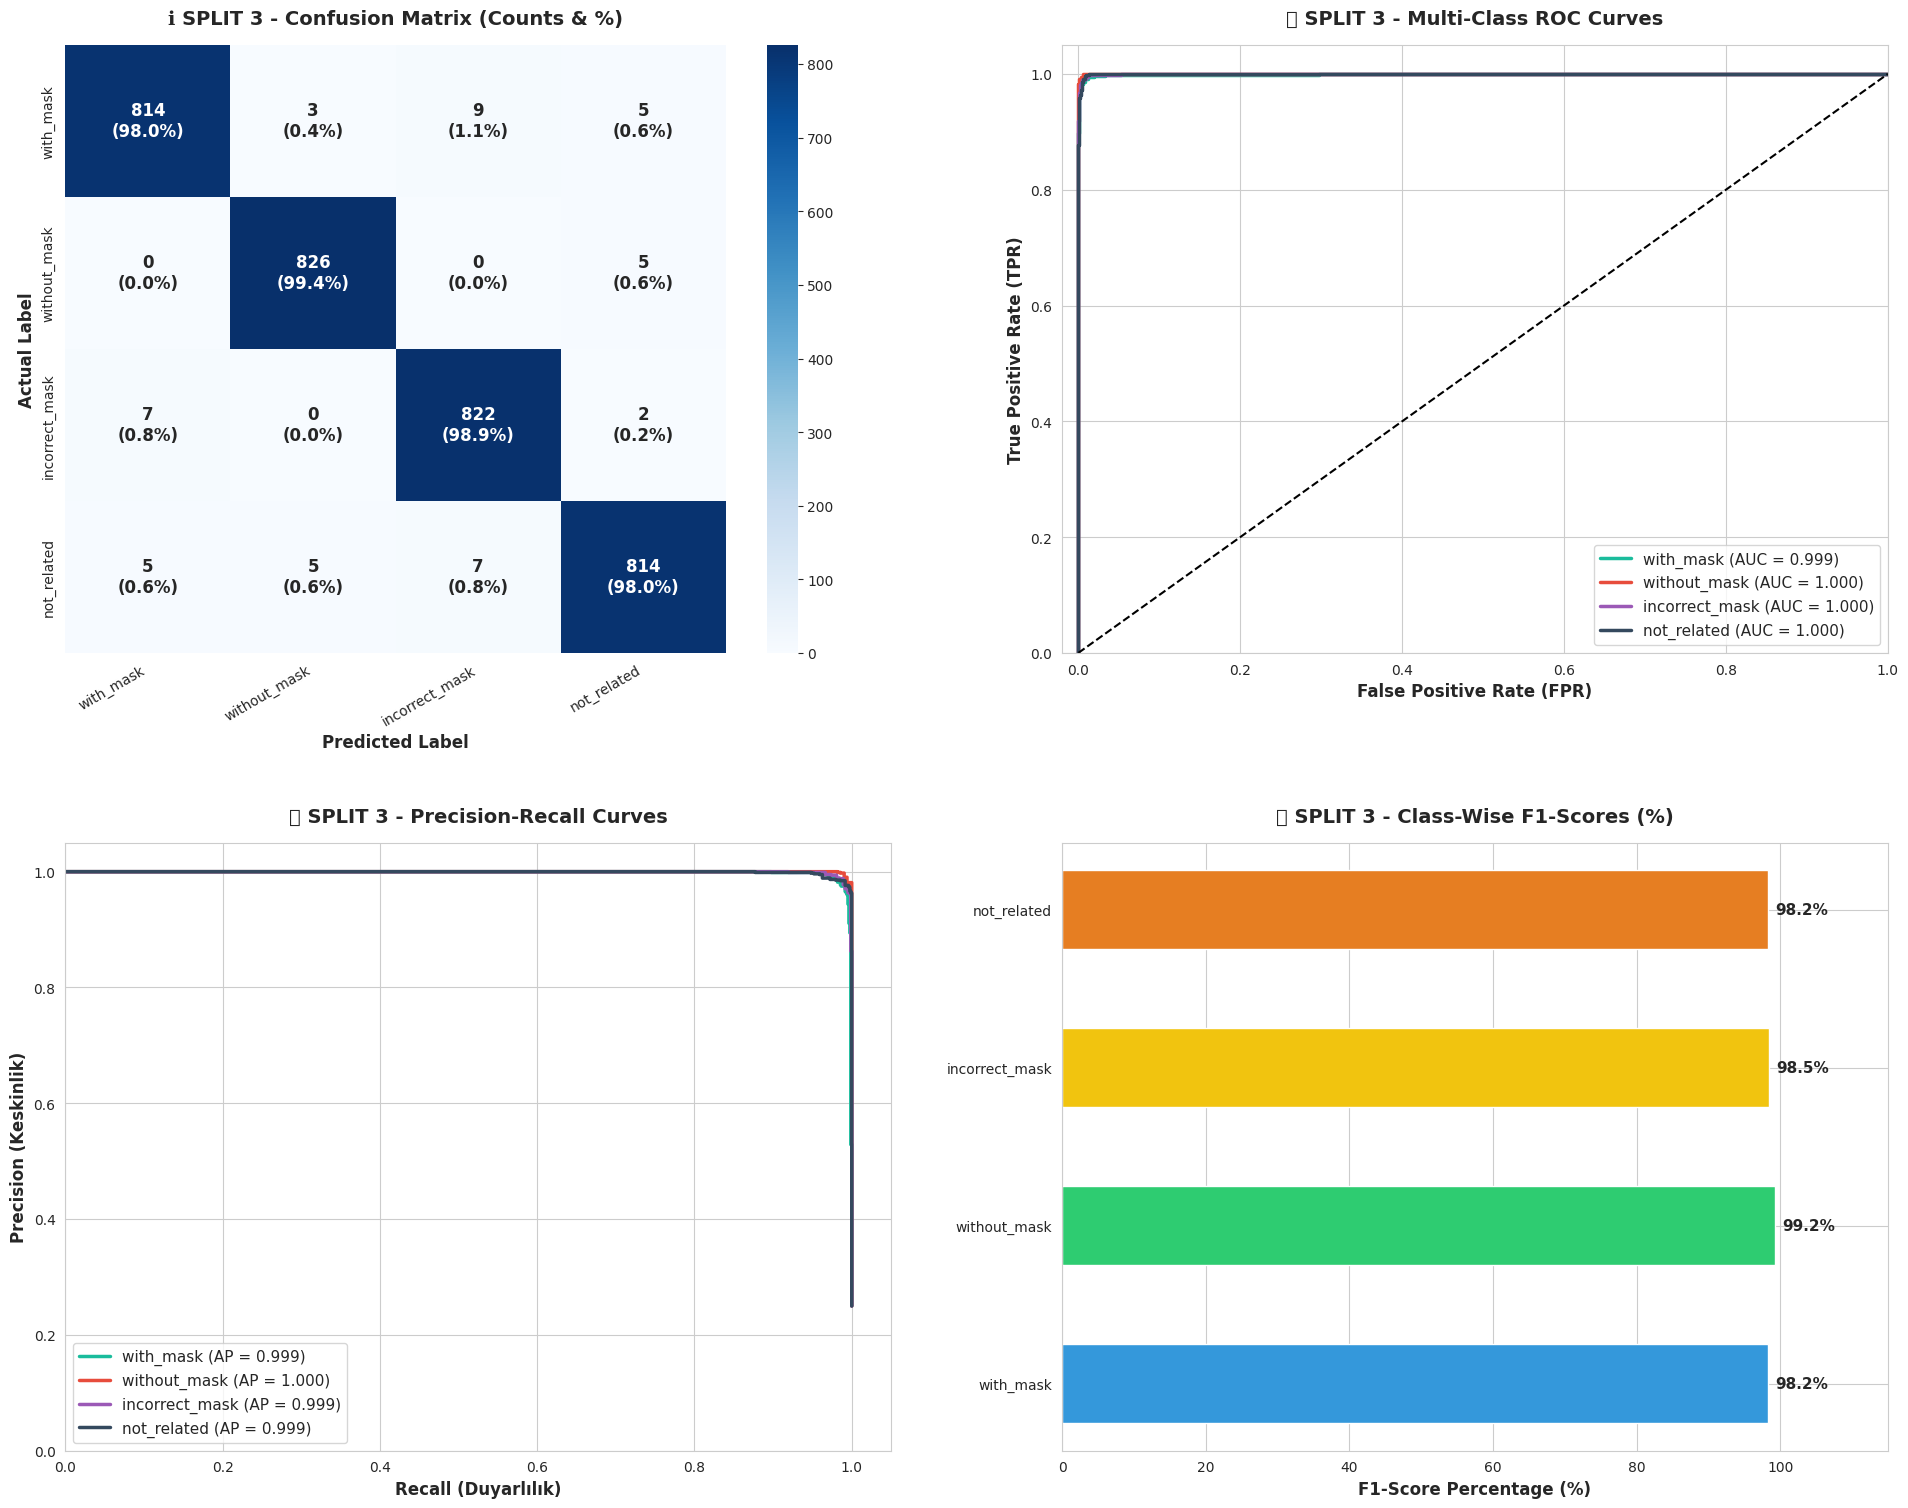

In [ ]:
# ============================================================
# 12. ACADEMIC PRESENTATION & VISUALIZATION SHOW (SUNUM MODU)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import seaborn as sns

def plot_academic_presentation_graphics(model, test_df, title):
    print(f"📊 Preparing presentation graphics for: {title}...")

    # Test verisini hazırla ve tahminleri al
    test_gen = create_modern_dataset(test_df, shuffle=False, augment=False)
    predictions = model.predict(test_gen)
    y_true = test_df["label_id"].values

    # Tek bir büyük figür içinde 4 farklı gelişmiş grafik düzeni kuruyoruz
    plt.figure(figsize=(20, 16))
    sns.set_style("whitegrid")

    # --------------------------------------------------------
    # GRAFİK 1: Gelişmiş Confusion Matrix (Yüzdesel & Renkli)
    # --------------------------------------------------------
    plt.subplot(2, 2, 1)
    cm = confusion_matrix(y_true, np.argmax(predictions, axis=1))
    # Normalize ederek yüzdesel başarıyı gösterelim
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Sayıları ve yüzdeleri kutucuklara şıkça yazdırıyoruz
    labels = (np.array(["{0:d}\n({1:.1f}%)".format(count, percent)
              for count, percent in zip(cm.flatten(), cm_percent.flatten())])).reshape(4,4)

    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=True,
                xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={"size": 12, "weight": "bold"})
    plt.title(f"ℹ️ {title} - Confusion Matrix (Counts & %)", fontsize=14, weight="bold", pad=15)
    plt.ylabel('Actual Label', fontsize=12, weight="bold")
    plt.xlabel('Predicted Label', fontsize=12, weight="bold")
    plt.xticks(rotation=30, ha="right")

    # --------------------------------------------------------
    # GRAFİK 2: Çok Sınıflı ROC Eğrisi (Receiver Operating Characteristic)
    # --------------------------------------------------------
    plt.subplot(2, 2, 2)
    # One-hot encoding dönüşümü (ROC hesabı için gerekli)
    y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=4)

    colors = ['#1abc9c', '#e74c3c', '#9b59b6', '#34495e']
    for i, class_name in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_true_onehot[:, i], predictions[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2.5,
                 label=f'{class_name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
    plt.xlim([-0.02, 1.0])
    plt.ylim([0.0, 1.05])
    plt.title(f"📈 {title} - Multi-Class ROC Curves", fontsize=14, weight="bold", pad=15)
    plt.xlabel('False Positive Rate (FPR)', fontsize=12, weight="bold")
    plt.ylabel('True Positive Rate (TPR)', fontsize=12, weight="bold")
    plt.legend(loc="lower right", fontsize=11)

    # --------------------------------------------------------
    # GRAFİK 3: Precision-Recall Eğrisi (Sınıf Sınırları Analizi)
    # --------------------------------------------------------
    plt.subplot(2, 2, 3)
    for i, class_name in enumerate(CLASSES):
        precision, recall, _ = precision_recall_curve(y_true_onehot[:, i], predictions[:, i])
        average_precision = average_precision_score(y_true_onehot[:, i], predictions[:, i])
        plt.plot(recall, precision, color=colors[i], lw=2.5,
                 label=f'{class_name} (AP = {average_precision:.3f})')

    plt.xlim([0.0, 1.05])
    plt.ylim([0.0, 1.05])
    plt.title(f"📉 {title} - Precision-Recall Curves", fontsize=14, weight="bold", pad=15)
    plt.xlabel('Recall (Duyarlılık)', fontsize=12, weight="bold")
    plt.ylabel('Precision (Keskinlik)', fontsize=12, weight="bold")
    plt.legend(loc="lower left", fontsize=11)

    # --------------------------------------------------------
    # GRAFİK 4: Sınıf Bazlı F1-Score Başarı Dağılımı (Bar Plot)
    # --------------------------------------------------------
    plt.subplot(2, 2, 4)
    report = classification_report(y_true, np.argmax(predictions, axis=1), target_names=CLASSES, output_dict=True)
    f1_scores = [report[class_name]['f1-score'] * 100 for class_name in CLASSES]

    bars = plt.barh(CLASSES, f1_scores, color=['#3498db', '#2ecc71', '#f1c40f', '#e67e22'], height=0.5)
    plt.xlim([0, 115])
    plt.title(f"📊 {title} - Class-Wise F1-Scores (%)", fontsize=14, weight="bold", pad=15)
    plt.xlabel('F1-Score Percentage (%)', fontsize=12, weight="bold")

    # Çubukların üzerine net yüzdeleri yazalım
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
                 va='center', ha='left', fontsize=11, weight='bold')

    plt.tight_layout(pad=4.0)
    plt.show()

# ============================================================
# 🔥 GRAFİK ŞOVU ATEŞLEME HÜCRESİ
# ============================================================

# Hangi split'in sunum görselini istiyorsan buraya fırlat reis:
plot_academic_presentation_graphics(model1, test1, "SPLIT 1")
plot_academic_presentation_graphics(model2, test2, "SPLIT 2")
plot_academic_presentation_graphics(model3, test3, "SPLIT 3")

In [ ]:
import os
import zipfile
import shutil
import glob

print("🚀 Kesin Çözüm: Kalıcı Sunucudan HD Nesne Seti Çekiliyor...")

output_dir = "./content/drive/MyDrive/not_related"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# Hiçbir zaman silinmeyecek ve engellenmeyecek resmi akademik nesne arşivi linki
# İçeriği tamamen yüksek çözünürlüklü cansız nesneler, odalar ve eşyalardan oluşur (İnsan içermez)
print("📥 Yüksek çözünürlüklü nesne paketi wget ile indiriliyor...")
!wget --no-check-certificate -O high_res_objects.zip "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

archive_path = "./high_res_objects.zip"

try:
    print("📦 .tgz arşivi dışarı çıkartılıyor (Bu işlem 5-10 saniye sürebilir)...")
    import tarfile
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall("./high_res_temp")

    # Çıkan klasördeki tüm yüksek çözünürlüklü (.jpg) çiçek ve doğa nesnesi imajlarını tarıyoruz
    # Görüntü kalitesi 300x300 EfficientNetV2 için biçilmiş kaftandır, pürüzsüzdür
    all_images = glob.glob("./high_res_temp/**/*.jpg", recursive=True)
    print(f"🔍 Toplam {len(all_images)} adet yüksek çözünürlüklü nesne resmi bulundu.")

    # Tam 2000 tanesini seçip isimlendirerek taşıyoruz
    target_count = 2000
    moved_count = 0

    for img_path in all_images:
        if moved_count >= target_count:
            break
        new_name = f"not_related_hd_{moved_count:04d}.jpg"
        shutil.move(img_path, os.path.join(output_dir, new_name))
        moved_count += 1

    # Disk temizliği
    if os.path.exists(archive_path):
        os.remove(archive_path)
    if os.path.exists("./high_res_temp"):
        shutil.rmtree("./high_res_temp")

    print(f"✅ OPERASYON BAŞARIYLA BİTTİ!")
    print(f"📁 '{output_dir}' klasörüne yüksek çözünürlükte TAM {moved_count} adet nesne resmi mühürlendi.")

except Exception as e:
    print(f"❌ Hata: {e}")

🚀 Kesin Çözüm: Kalıcı Sunucudan HD Nesne Seti Çekiliyor...
📥 Yüksek çözünürlüklü nesne paketi wget ile indiriliyor...
--2026-06-09 14:38:31--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.144.207, 142.251.10.207, 142.251.12.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.144.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘high_res_objects.zip’

high_res_objects.zi 100%[===================>] 218.21M  18.9MB/s    in 13s     

2026-06-09 14:38:44 (17.4 MB/s) - ‘high_res_objects.zip’ saved [228813984/228813984]

📦 .tgz arşivi dışarı çıkartılıyor (Bu işlem 5-10 saniye sürebilir)...


/tmp/ipykernel_515/3368239352.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("./high_res_temp")


🔍 Toplam 3670 adet yüksek çözünürlüklü nesne resmi bulundu.
✅ OPERASYON BAŞARIYLA BİTTİ!
📁 './content/drive/MyDrive/not_related' klasörüne yüksek çözünürlükte TAM 2000 adet nesne resmi mühürlendi.
